<a href="https://colab.research.google.com/github/adityaraghavan98/camm_hackathon/blob/k4my4r/docs/day_19_02102026/Aditya_Higher_Dimensional_Optical_Data_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="red">**Higher-Dimensional Optical Data Visualization Challenge**</font>

## Composition → spectrum → measurement context

### The problem

Optical libraries are difficult to visualize because every sample has a composition,
a full spectrum, a measurement geometry, and sometimes an elapsed-time history. A
collection of separate plots makes comparisons slow, but forcing everything into one
crowded plot can hide the spectral evidence.

> **Can we make all of those variables easier to explore without hiding the spectra
> or compressing the experiment into a single unexplained score?**

### The approach

Like the example EELS hackathon notebook, this notebook follows one linear pattern:

1. inspect the data and its dimensions;
2. run one complete, deliberately simple worked example;
3. modify that baseline in a clearly marked challenge cell;
4. test whether a new user can answer the stated scientific question.

### Choose one challenge

1. **Challenge 1 — Quaternary System:** connect FA/Cs/Rb/DMA composition and I/Br variation to
   Top PL, Bottom PL, and absorbance.
2. **Challenge 2 — RP-Additive System:** connect 3AMP/FAPbI3 host composition and nominal MACl
   level to Top/Bottom PL over 0–380 minutes.

### Your final result

- one visualization that answers a specific scientific question;
- the full spectral evidence remains reachable or visible;
- one sentence explaining what became easier to see and one possible misinterpretation.

The worked examples are deliberately simple baselines not
the expected final answer.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbarakati/athena_camm_hackathon/blob/k4my4r/docs/day_19_02102026/Higher_Dimensional_Optical_Data_Hackathon.ipynb)

<h2><font color="purple">1.</font> Download and Load the Data</h2>

Run the next cells from top to bottom. One public Google Drive folder contains both
challenge folders. The download cell is safe to rerun: it reuses a verified local copy
and only downloads again when files are missing or changed.


In [1]:
# @title 1. Install and import the small analysis stack
%pip -q install "gdown==6.4.1" "pyarrow>=14" "plotly>=5.22"

from html import escape
from pathlib import Path
import hashlib
import shutil
import sys

import gdown
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from IPython.display import FileLink, HTML, Markdown, display


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 1.3 MB/s eta 0:00:00


In [2]:
# @title 2. Download both challenge folders from Google Drive
DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/16YfPjFdZHgW3hkC0QBLrCS9um2C6aK5q?usp=drive_link"
IN_COLAB = "google.colab" in sys.modules
DATA_ROOT = Path(
    "/content/higher_dimensional_optical_data"
    if IN_COLAB else "./.higher_dimensional_optical_data"
).resolve()
STAGING_ROOT = DATA_ROOT.with_name(DATA_ROOT.name + "_download")

REMOTE_QUATERNARY_FOLDER = "01_hochan_quaternary_data"
EXPECTED_MANIFEST_HASHES = {
    REMOTE_QUATERNARY_FOLDER: "6c4f5329411f7897b16578ec3f029f092ca05eb99a884a9a622b1ffabf24ff8e",
    "02_rp_additive_data": "0060b641f417179122562eefb6d5acee527b4927796fd4a595631b683fded38c",
}

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def folder_errors(root):
    errors = []
    for folder_name, expected_manifest_hash in EXPECTED_MANIFEST_HASHES.items():
        folder = root / folder_name
        checksum_path = folder / "SHA256SUMS.txt"
        if not checksum_path.is_file():
            errors.append(f"missing: {folder_name}/SHA256SUMS.txt")
            continue
        if file_sha256(checksum_path) != expected_manifest_hash:
            errors.append(f"unexpected checksum manifest: {folder_name}")
            continue
        for line in checksum_path.read_text(encoding="utf-8").strip().splitlines():
            expected, relative = line.split("  ", 1)
            path = folder / relative
            if not path.is_file():
                errors.append(f"missing: {folder_name}/{relative}")
            elif file_sha256(path) != expected:
                errors.append(f"checksum mismatch: {folder_name}/{relative}")
    return errors

def locate_download_root(root):
    candidates = [root] + sorted(
        (path for path in root.rglob("*") if path.is_dir()),
        key=lambda path: len(path.parts),
    )
    matches = [
        path for path in candidates
        if (path / REMOTE_QUATERNARY_FOLDER).is_dir()
        and (path / "02_rp_additive_data").is_dir()
    ]
    if len(matches) != 1:
        raise RuntimeError(
            "Expected one downloaded parent containing both challenge folders; "
            f"found {len(matches)}."
        )
    return matches[0]

errors = folder_errors(DATA_ROOT)
if errors:
    if STAGING_ROOT.exists():
        shutil.rmtree(STAGING_ROOT)
    STAGING_ROOT.mkdir(parents=True)
    print("Downloading both challenge datasets from Google Drive ...")
    try:
        downloaded = gdown.download_folder(
            url=DRIVE_FOLDER_URL,
            output=str(STAGING_ROOT),
            quiet=False,
            use_cookies=False,
        )
        if not downloaded:
            raise RuntimeError("Google Drive returned no files.")
        downloaded_root = locate_download_root(STAGING_ROOT)
        errors = folder_errors(downloaded_root)
        if errors:
            raise RuntimeError("Downloaded data failed verification:\n- " + "\n- ".join(errors))

        if DATA_ROOT.exists():
            shutil.rmtree(DATA_ROOT)
        if downloaded_root == STAGING_ROOT:
            STAGING_ROOT.rename(DATA_ROOT)
        else:
            shutil.move(str(downloaded_root), str(DATA_ROOT))
            shutil.rmtree(STAGING_ROOT, ignore_errors=True)
    except Exception as exc:
        shutil.rmtree(STAGING_ROOT, ignore_errors=True)
        raise RuntimeError(
            "Data setup failed. Confirm that the shared parent folder and its contents "
            "are set to 'Anyone with the link - Viewer', then rerun this cell."
        ) from exc
    print("Download complete; every file passed SHA-256 verification.")
else:
    print("Verified data already present; no download needed.")

QUATERNARY_DIR = DATA_ROOT / REMOTE_QUATERNARY_FOLDER
RP_DIR = DATA_ROOT / "02_rp_additive_data"
print("Challenge 1 — Quaternary System: ready")
print("Challenge 2 — RP-Additive System: ready")


Retrieving folder 1lKab_j038FiNxPvNzHtnMUv_U9es1gN7 01_hochan_quaternary_data


Retrieving folder contents


Processing file 1Z20at8pdv7XnxWKYNDkNUDtzwHMHnrOu composition_and_recipe.csv
Processing file 1lIYfpqZTv7B1rU9QVv3zWyK7QP_xaZn6 measurement_manifest.csv
Processing file 16JOB1gy7TrfBvBp68hgJR4FcQjw_c5lZ optical_read_qc_summary.csv
Processing file 1VIJhV0YhdqfpmMIZxljMzWyOwWc1pYnz optical_spectra_long.parquet
Processing file 19Gmib_Jf0RhhJCsw_R9oxpNxfQmQG-9g README_DATA.md
Processing file 1h-cmt1usy-jDRkRNU3VqWZtR_Xo7DFOW SHA256SUMS.txt
Retrieving folder 1XCDHKsa7-_pmEmpH1EPpArxUlf54HvIH 02_rp_additive_data
Processing file 1bTvZUNQbc7FtEtNSXDBBGGoe000OPvcz composition_and_recipe.csv
Processing file 1qJ8wxyUdn_1rSESAV8bm_LJcsIBK0QJV metadata_features.parquet
Processing file 1Rz8SY732Cbf7oONnmumZcxE8Dt2a1lmt README_DATA.md
Processing file 1Rl82CZGXM248CoWYgy9KmJvBzspEg5rm SHA256SUMS.txt
Processing file 1nGx6ng2If1IlFK_l4lSGXlLzbgbWR1Lc spectra_wide.parquet


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Z20at8pdv7XnxWKYNDkNUDtzwHMHnrOu
To: /content/higher_dimensional_optical_data_download/01_hochan_quaternary_data/composition_and_recipe.csv
100%|██████████| 20.5k/20.5k [00:00<00:00, 29.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1lIYfpqZTv7B1rU9QVv3zWyK7QP_xaZn6
To: /content/higher_dimensional_optical_data_download/01_hochan_quaternary_data/measurement_manifest.csv
100%|██████████| 692/692 [00:00<00:00, 1.84MB/s]
Downloading...
From: https://drive.google.com/uc?id=16JOB1gy7TrfBvBp68hgJR4FcQjw_c5lZ
To: /content/higher_dimensional_optical_data_download/01_hochan_quaternary_data/optical_read_qc_summary.csv
100%|██████████| 630/630 [00:00<00:00, 1.73MB/s]
Downloading...
From: https://drive.google.com/uc?id=1VIJhV0YhdqfpmMIZxljMzWyOwWc1pYnz
To: /content/higher_dimensional_optical_data_download/01_hochan_quaternary_data/

Download complete; every file passed SHA-256 verification.
Challenge 1 — Quaternary System: ready
Challenge 2 — RP-Additive System: ready



Download completed


In [3]:
# @title 3. Load the prepared tables
QUATERNARY_COMPOSITION_PATH = QUATERNARY_DIR / "composition_and_recipe.csv"
RP_COMPOSITION_PATH = RP_DIR / "composition_and_recipe.csv"

quaternary_composition = pd.read_csv(QUATERNARY_COMPOSITION_PATH)
quaternary_optical = pd.read_parquet(QUATERNARY_DIR / "optical_spectra_long.parquet")
quaternary_manifest = pd.read_csv(QUATERNARY_DIR / "measurement_manifest.csv")

rp_composition = pd.read_csv(RP_COMPOSITION_PATH)
rp_features = pd.read_parquet(RP_DIR / "metadata_features.parquet")
rp_spectra = pd.read_parquet(RP_DIR / "spectra_wide.parquet")

rp_wavelength_columns = sorted(
    (column for column in rp_spectra if column.startswith("wl_")),
    key=lambda column: float(column.split("_", 1)[1]),
)
rp_wavelengths = np.asarray([
    float(column.split("_", 1)[1]) for column in rp_wavelength_columns
])
rp_spectra_by_id = rp_spectra.set_index("spectrum_id")


In [4]:
# @title 4. Run compact scientific-structure checks
assert len(quaternary_composition) == quaternary_composition["well"].nunique() == 96
assert set(quaternary_composition["well"]) == set(quaternary_optical["well"])
assert set(quaternary_optical["geometry"]) == {"Top", "Bottom", "Absorbance"}

a_site = ["FA_fraction", "Cs_fraction", "Rb_fraction", "DMA_fraction"]
x_site = ["I_fraction", "Br_fraction", "Cl_fraction"]
assert np.allclose(quaternary_composition[a_site].sum(axis=1), 1.0)
assert np.allclose(quaternary_composition[x_site].sum(axis=1), 1.0)

assert len(rp_composition) == rp_composition["well"].nunique() == 96
assert set(rp_composition["well"]) == set(rp_features["well"])
assert len(rp_features) == rp_features["spectrum_id"].nunique() == 3840
assert set(rp_features["spectrum_id"]) == set(rp_spectra["spectrum_id"])
assert np.allclose(
    rp_composition["spacer_host_fraction"]
    + rp_composition["FAPbI3_host_fraction"],
    1.0,
)

coverage = pd.DataFrame([
    {
        "challenge": "Challenge 1 — Quaternary System",
        "wells": quaternary_composition["well"].nunique(),
        "spectra": quaternary_optical.groupby(["well", "geometry"]).ngroups,
        "times": "none",
        "measurements": "Top PL, Bottom PL, absorbance",
    },
    {
        "challenge": "Challenge 2 — RP-Additive System",
        "wells": rp_composition["well"].nunique(),
        "spectra": len(rp_features),
        "times": rp_features["time_min"].nunique(),
        "measurements": "Top PL, Bottom PL",
    },
])
display(Markdown("### Data ready — all integrity and structure checks passed"))
display(coverage)


### Data ready — all integrity and structure checks passed

,challenge,wells,spectra,times,measurements
0,Challenge 1 — Quaternary System,96,288,none,"Top PL, Bottom PL, absorbance"
1,Challenge 2 — RP-Additive System,96,3840,20,"Top PL, Bottom PL"


## What is “high-dimensional” here?

| Challenge | Composition variables | Measurement variables | Spectral variable |
|---|---|---|---|
| Quaternary System | FA, Cs, Rb, DMA; I/Br slice | Top PL, Bottom PL, absorbance | wavelength |
| RP-Additive System | 3AMP/FAPbI3 host fraction; nominal MACl level | time; Top/Bottom PL | wavelength |

Two guardrails matter throughout:

- In the Quaternary System, **Top and Bottom are collection geometries**, not time
  points or replicates.
- In the RP-Additive System, MACl percentage is a **nominal design level with
  undocumented basis**,
  not a third closed-composition fraction.

PL peaks and spectral summaries are optical observations—not structural phase labels.

### Possible visualization strategies

There is no single required chart type. Useful solution families include:

- **small multiples:** reserve panels for composition slices, geometry, or time;
- **overview + detail:** use a composition map to navigate to complete spectra;
- **interactive controls:** let the user select a well, time, geometry, or metric;
- **change encodings:** show Top − Bottom or final − initial values with a shared scale;
- **spectral-first views:** use heatmaps, trajectories, or compact spectral glyphs.

The worked examples below use **overview + detail**. They are starting points, not the
intended final answer. Figures are stacked at full width by default so labels, legends,
and color scales stay readable in Colab.


In [5]:
# Inspect or download the two one-row-per-well composition tables
display(Markdown("#### Challenge 1 — Quaternary System composition and recipe"))
display(quaternary_composition.head(6))
display(FileLink(
    str(QUATERNARY_COMPOSITION_PATH), result_html_prefix="Download full CSV: "
))

display(Markdown("#### Challenge 2 — RP-Additive System composition and recipe"))
display(rp_composition.head(6))
display(FileLink(str(RP_COMPOSITION_PATH), result_html_prefix="Download full CSV: "))


#### Challenge 1 — Quaternary System composition and recipe

,well,row,col,FA_fraction,Cs_fraction,Rb_fraction,DMA_fraction,I_fraction,Br_fraction,Cl_fraction,...,Br_design_percent,total_volume_uL,FAPbI3_volume_uL,FAPbBr3_volume_uL,RbPbI3_volume_uL,DMAPbI3_volume_uL,CsPbI3_volume_uL,CsPbI05Br05_volume_uL,composition_label,composition_basis
0,A1,A,1,0.900,0.1,0.0,0.000,1.0000,0.0000,0.0,...,0.000000,100.0,90.0,0.0,0.0,0.0,10.0,0.0,FA 0.900 | Cs 0.100 | Rb 0.000 | DMA 0.000 || ...,nominal_equal_molar_stock_volume
1,A2,A,2,0.875,0.1,0.0,0.025,1.0000,0.0000,0.0,...,0.000000,100.0,87.5,0.0,0.0,2.5,10.0,0.0,FA 0.875 | Cs 0.100 | Rb 0.000 | DMA 0.025 || ...,nominal_equal_molar_stock_volume
2,A3,A,3,0.850,0.1,0.0,0.050,1.0000,0.0000,0.0,...,0.000000,100.0,85.0,0.0,0.0,5.0,10.0,0.0,FA 0.850 | Cs 0.100 | Rb 0.000 | DMA 0.050 || ...,nominal_equal_molar_stock_volume
3,A4,A,4,0.800,0.1,0.0,0.100,1.0000,0.0000,0.0,...,0.000000,100.0,80.0,0.0,0.0,10.0,10.0,0.0,FA 0.800 | Cs 0.100 | Rb 0.000 | DMA 0.100 || ...,nominal_equal_molar_stock_volume
4,A5,A,5,0.900,0.1,0.0,0.000,0.8335,0.1665,0.0,...,16.666667,100.0,75.0,15.0,0.0,0.0,6.7,3.3,FA 0.900 | Cs 0.100 | Rb 0.000 | DMA 0.000 || ...,nominal_equal_molar_stock_volume
5,A6,A,6,0.875,0.1,0.0,0.025,0.8335,0.1665,0.0,...,16.666667,100.0,72.5,15.0,0.0,2.5,6.7,3.3,FA 0.875 | Cs 0.100 | Rb 0.000 | DMA 0.025 || ...,nominal_equal_molar_stock_volume


/content/higher_dimensional_optical_data/01_hochan_quaternary_data/composition_and_recipe.csv

#### Challenge 2 — RP-Additive System composition and recipe

,well,row,col,library,base_spacer,additive,spacer_host_fraction,FAPbI3_host_fraction,spacer_percent,FAPbI3_percent,additive_percent,spacer_stock_volume_uL,FAPbI3_stock_volume_uL,additive_stock_volume_uL,host_total_uL,total_mix_volume_uL,composition_label,composition_basis
0,A1,A,1,3AMP-FA with MACl,3AMP,MACl,1.000000,0.000000,100.000000,0.000000,0.0,50.00,0.00,0.0,50.0,50.0,3AMP:1.00 FA:0.00 MACl:0%,host_fraction_from_nominal_stock_volume;additi...
1,A2,A,2,3AMP-FA with MACl,3AMP,MACl,0.909091,0.090909,90.909091,9.090909,0.0,45.45,4.55,0.0,50.0,50.0,3AMP:0.91 FA:0.09 MACl:0%,host_fraction_from_nominal_stock_volume;additi...
2,A3,A,3,3AMP-FA with MACl,3AMP,MACl,0.818182,0.181818,81.818182,18.181818,0.0,40.91,9.09,0.0,50.0,50.0,3AMP:0.82 FA:0.18 MACl:0%,host_fraction_from_nominal_stock_volume;additi...
3,A4,A,4,3AMP-FA with MACl,3AMP,MACl,0.727273,0.272727,72.727273,27.272727,0.0,36.36,13.64,0.0,50.0,50.0,3AMP:0.73 FA:0.27 MACl:0%,host_fraction_from_nominal_stock_volume;additi...
4,A5,A,5,3AMP-FA with MACl,3AMP,MACl,0.636364,0.363636,63.636364,36.363636,0.0,31.82,18.18,0.0,50.0,50.0,3AMP:0.64 FA:0.36 MACl:0%,host_fraction_from_nominal_stock_volume;additi...
5,A6,A,6,3AMP-FA with MACl,3AMP,MACl,0.545455,0.454545,54.545455,45.454545,0.0,27.27,22.73,0.0,50.0,50.0,3AMP:0.55 FA:0.45 MACl:0%,host_fraction_from_nominal_stock_volume;additi...


/content/higher_dimensional_optical_data/02_rp_additive_data/composition_and_recipe.csv

In [6]:
# Responsive display/export helpers used by both worked examples.
# One column is the readable Colab default; use columns=2 only on a wide display.
def show_figures(figures, columns=1):
    if columns not in (1, 2):
        raise ValueError("columns must be 1 or 2")
    blocks = [
        "<div style='min-width:0;width:100%;overflow-x:auto'>"
        + pio.to_html(
            figure,
            include_plotlyjs="cdn" if index == 0 else False,
            full_html=False,
            config={"responsive": True, "displaylogo": False},
        )
        + "</div>"
        for index, figure in enumerate(figures)
    ]
    grid_class = f"hd-figure-grid-{columns}"
    display(HTML(
        f"<style>.{grid_class}{{display:grid;grid-template-columns:repeat("
        f"{columns},minmax(0,1fr));gap:28px;align-items:start;width:100%;"
        "max-width:1200px;margin:0 auto}}"
        f"@media(max-width:1100px){{.{grid_class}{{grid-template-columns:1fr}}}}"
        "</style>"
        f"<div class='{grid_class}'>" + "".join(blocks) + "</div>"
    ))

def export_figure_grid(figures, path, title, columns=1):
    if columns not in (1, 2):
        raise ValueError("columns must be 1 or 2")
    blocks = [
        pio.to_html(
            figure,
            include_plotlyjs=True if index == 0 else False,
            full_html=False,
            config={"responsive": True, "displaylogo": False},
        )
        for index, figure in enumerate(figures)
    ]
    document = (
        "<!doctype html><meta charset='utf-8'><title>" + escape(title) + "</title>"
        "<style>body{font-family:Arial;margin:24px;color:#172b4d}"
        ".grid{display:grid;gap:28px;max-width:1200px;margin:0 auto}"
        f".grid{{grid-template-columns:repeat({columns},minmax(0,1fr))}}"
        "@media(max-width:1100px){.grid{grid-template-columns:1fr}}"
        ".grid>div{min-width:0;width:100%;overflow-x:auto}</style>"
        "<h1>" + escape(title) + "</h1><div class='grid'>"
        + "".join("<div>" + block + "</div>" for block in blocks)
        + "</div>"
    )
    Path(path).write_text(document, encoding="utf-8")
    return Path(path)


<h2><font color="purple">2.</font> Explore the Quaternary System</h2>

### Problem 1

> **Where do Top and Bottom PL disagree across composition, and what additional
> context does absorbance provide?**

The A-site fractions **FA + Cs + Rb + DMA = 1**. The X-site fractions
**I + Br + Cl = 1** separately. Never normalize all seven fractions together.

A conventional ternary diagram is not enough because the A-site contains four
components and the plate also varies halide composition. The baseline solution uses
**small-multiple composition slices** for overview and a separate **full-spectrum
detail view** for evidence.

We will first create a small well-level feature table. These scalar features are
navigation aids; the full spectra remain the evidence.


In [7]:
# Summarize each Quaternary System PL spectrum without changing the source data
integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

def summarize_pl(group):
    ordered = group.sort_values("wavelength_nm")
    wavelength = ordered["wavelength_nm"].to_numpy(float)
    raw = ordered["optical_signal_instrument_units"].to_numpy(float)
    signal = np.clip(raw - np.nanpercentile(raw, 5), 0, None)
    area = float(integrate(signal, wavelength))
    peak = float(wavelength[int(np.nanargmax(signal))])
    centroid = float(np.sum(wavelength * signal) / signal.sum())
    return pd.Series({
        "dominant_peak_nm": peak,
        "centroid_nm": centroid,
        "log10_integrated_pl": np.log10(area),
    })

quaternary_pl_features = (
    quaternary_optical[quaternary_optical["modality"].eq("PL")]
    .groupby(["well", "geometry"], sort=False)[
        ["wavelength_nm", "optical_signal_instrument_units"]
    ]
    .apply(summarize_pl)
    .reset_index()
)


In [8]:
# Assemble one row per well for composition-space visualization
pl_wide = quaternary_pl_features.pivot(
    index="well", columns="geometry",
    values=["dominant_peak_nm", "centroid_nm", "log10_integrated_pl"],
)
pl_wide.columns = [
    f"{geometry}_{metric}" for metric, geometry in pl_wide.columns
]
pl_wide = pl_wide.reset_index()

absorbance_points = (
    quaternary_optical[
        quaternary_optical["modality"].eq("Absorbance")
        & quaternary_optical["wavelength_nm"].isin([450, 650, 750])
    ]
    .pivot(index="well", columns="wavelength_nm",
           values="optical_signal_instrument_units")
    .rename(columns=lambda value: f"Abs_signal_{int(value)}nm")
    .reset_index()
)

quaternary_features = (
    quaternary_composition.merge(pl_wide, on="well", validate="one_to_one")
    .merge(absorbance_points, on="well", validate="one_to_one")
)
quaternary_features["Top_minus_Bottom_peak_nm"] = (
    quaternary_features["Top_dominant_peak_nm"]
    - quaternary_features["Bottom_dominant_peak_nm"]
)
quaternary_features["Top_minus_Bottom_centroid_nm"] = (
    quaternary_features["Top_centroid_nm"]
    - quaternary_features["Bottom_centroid_nm"]
)
display(quaternary_features.head())


,well,row,col,FA_fraction,Cs_fraction,Rb_fraction,DMA_fraction,I_fraction,Br_fraction,Cl_fraction,...,Top_dominant_peak_nm,Bottom_centroid_nm,Top_centroid_nm,Bottom_log10_integrated_pl,Top_log10_integrated_pl,Abs_signal_450nm,Abs_signal_650nm,Abs_signal_750nm,Top_minus_Bottom_peak_nm,Top_minus_Bottom_centroid_nm
0,A1,A,1,0.900,0.1,0.0,0.000,1.0000,0.0000,0.0,...,796.0,798.670772,793.513213,5.074690,4.641999,1.137,0.784,0.638,-8.0,-5.157559
1,A2,A,2,0.875,0.1,0.0,0.025,1.0000,0.0000,0.0,...,800.0,799.003212,793.793578,5.127319,4.654614,0.982,0.944,0.818,1.0,-5.209634
2,A3,A,3,0.850,0.1,0.0,0.050,1.0000,0.0000,0.0,...,785.0,786.070694,777.495514,4.930852,4.427226,0.754,0.553,0.471,-4.0,-8.575180
3,A4,A,4,0.800,0.1,0.0,0.100,1.0000,0.0000,0.0,...,777.0,778.954967,771.642733,5.030859,4.551035,0.721,0.490,0.416,-7.0,-7.312234
4,A5,A,5,0.900,0.1,0.0,0.000,0.8335,0.1665,0.0,...,752.0,751.787562,746.566288,5.200939,4.726454,0.987,0.612,0.456,-6.0,-5.221274


In [9]:
# Reusable Challenge 1 composition overview
QUATERNARY_METRICS = {
    "Top_minus_Bottom_peak_nm": "Top - Bottom dominant peak (nm)",
    "Top_minus_Bottom_centroid_nm": "Top - Bottom centroid (nm)",
    "Top_dominant_peak_nm": "Top dominant peak (nm)",
    "Bottom_dominant_peak_nm": "Bottom dominant peak (nm)",
    "Abs_signal_650nm": "Absorbance signal at 650 nm",
}
QUATERNARY_COLORBAR_TITLES = {
    "Top_minus_Bottom_peak_nm": "Δ peak<br>(nm)",
    "Top_minus_Bottom_centroid_nm": "Δ centroid<br>(nm)",
    "Top_dominant_peak_nm": "Top peak<br>(nm)",
    "Bottom_dominant_peak_nm": "Bottom peak<br>(nm)",
    "Abs_signal_650nm": "Absorbance<br>at 650 nm",
}

def quaternary_overview(metric="Top_minus_Bottom_peak_nm"):
    diverging = metric.startswith("Top_minus_Bottom")
    figure = px.scatter(
        quaternary_features,
        x="Rb_design_percent", y="DMA_design_percent", color=metric,
        facet_row="Cs_design_percent", facet_col="Br_design_percent",
        category_orders={
            "Cs_design_percent": sorted(
                quaternary_features["Cs_design_percent"].unique(), reverse=True
            ),
            "Br_design_percent": sorted(
                quaternary_features["Br_design_percent"].unique()
            ),
        },
        custom_data=["well", "FA_fraction", "I_fraction", "Br_fraction"],
        labels={
            "Rb_design_percent": "Rb design level (%)",
            "DMA_design_percent": "DMA design level (%)",
            metric: QUATERNARY_METRICS[metric],
        },
        color_continuous_scale="RdBu_r" if diverging else "Viridis",
        color_continuous_midpoint=0 if diverging else None,
        title=(
            "All 96 compositions"
            f"<br><sup>Color: {QUATERNARY_METRICS[metric]}</sup>"
        ),
        height=760,
    )
    figure.update_traces(
        marker={"size": 16, "line": {"color": "white", "width": 1}},
        hovertemplate=(
            "<b>Well %{customdata[0]}</b><br>Rb %{x:g}%<br>DMA %{y:g}%<br>"
            "FA %{customdata[1]:.3f}<br>I %{customdata[2]:.3f}<br>"
            "Br %{customdata[3]:.3f}<br>Value %{marker.color:.4g}<extra></extra>"
        ),
    )
    figure.for_each_annotation(
        lambda annotation: annotation.update(
            text=annotation.text
            .replace("Cs_design_percent=", "Cs = ")
            .replace("Br_design_percent=", "Br = ")
            + "%"
        )
    )
    figure.update_coloraxes(colorbar={
        "title": {
            "text": QUATERNARY_COLORBAR_TITLES[metric], "side": "right"
        },
        "thickness": 18,
        "len": 0.72,
        "x": 1.02,
    })
    figure.update_xaxes(automargin=True)
    figure.update_yaxes(automargin=True)
    figure.update_layout(
        template="plotly_white", autosize=True,
        margin={"l": 75, "r": 135, "t": 110, "b": 80},
        title={"x": 0.01, "xanchor": "left"},
    )
    return figure


In [10]:
# Reusable Challenge 1 full-spectrum view
def quaternary_spectra(well="H8"):
    sample = quaternary_optical[quaternary_optical["well"].eq(well)]
    composition = quaternary_composition[
        quaternary_composition["well"].eq(well)
    ].iloc[0]
    figure = make_subplots(
        rows=2, cols=1, vertical_spacing=0.18,
        subplot_titles=("Top and Bottom PL shape", "Absorbance channel"),
    )
    for geometry, color in [("Top", "#2563eb"), ("Bottom", "#f97316")]:
        rows = sample[sample["geometry"].eq(geometry)].sort_values("wavelength_nm")
        wavelength = rows["wavelength_nm"].to_numpy(float)
        raw = rows["optical_signal_instrument_units"].to_numpy(float)
        signal = np.clip(raw - np.nanpercentile(raw, 5), 0, None)
        signal = signal / signal.max()
        figure.add_trace(go.Scatter(
            x=wavelength, y=signal, mode="lines", name=f"{geometry} PL",
            line={"color": color, "width": 2.5},
        ), row=1, col=1)

    absorbance = sample[sample["geometry"].eq("Absorbance")].sort_values("wavelength_nm")
    figure.add_trace(go.Scatter(
        x=absorbance["wavelength_nm"],
        y=absorbance["optical_signal_instrument_units"],
        mode="lines", name="Absorbance", line={"color": "#059669", "width": 2.5},
    ), row=2, col=1)
    subtitle = (
        f"FA {composition.FA_fraction:.3f} | Cs {composition.Cs_fraction:.3f} | "
        f"Rb {composition.Rb_fraction:.3f} | DMA {composition.DMA_fraction:.3f} | "
        f"I {composition.I_fraction:.3f} | Br {composition.Br_fraction:.3f}"
    )
    figure.update_xaxes(title_text="Wavelength (nm)", row=2, col=1)
    figure.update_yaxes(title_text="Peak-normalized PL", row=1, col=1)
    figure.update_yaxes(title_text="Instrument units", row=2, col=1)
    figure.update_layout(
        title=f"Well {well}<br><sup>{subtitle}</sup>", height=760,
        template="plotly_white", hovermode="x unified", autosize=True,
        margin={"l": 85, "r": 45, "t": 105, "b": 75},
        title_x=0.01,
    )
    return figure


# Worked Example — Quaternary System

### Question

Where do Top and Bottom PL have different dominant peaks, and what do the complete
spectra look like at one selected composition?

### Baseline solution

The overview uses small multiples for Cs and Br, Rb/DMA position, and color for the
optical difference. The second figure shows Top PL, Bottom PL, and absorbance for well
H8. Hover retains the well and composition details. The figures are intentionally
stacked so neither is squeezed into half of the notebook width.


In [11]:
QUATERNARY_EXAMPLE_WELL = "H8"
quaternary_example_figures = [
    quaternary_overview("Top_minus_Bottom_peak_nm"),
    quaternary_spectra(QUATERNARY_EXAMPLE_WELL),
]
show_figures(quaternary_example_figures)

record = quaternary_features[
    quaternary_features["well"].eq(QUATERNARY_EXAMPLE_WELL)
].iloc[0]
display(Markdown(f'''
### What did we just do?

At **{QUATERNARY_EXAMPLE_WELL}**, the Top-minus-Bottom
dominant-peak difference is **{record.Top_minus_Bottom_peak_nm:+.0f} nm**, while the
centroid difference is **{record.Top_minus_Bottom_centroid_nm:+.2f} nm**. Those two
summaries can even disagree in sign, which is why the full line shapes remain visible.
This is an optical comparison, not a phase assignment.
'''))



### What did we just do?

At **H8**, the Top-minus-Bottom
dominant-peak difference is **+11 nm**, while the
centroid difference is **-2.89 nm**. Those two
summaries can even disagree in sign, which is why the full line shapes remain visible.
This is an optical comparison, not a phase assignment.


# <font color="red">Challenge 1 — Quaternary System</font>

### Your task

Improve the baseline so a new user can connect the four A-site fractions, halide
level, measurement geometry, and full spectra more quickly or more accurately.

### Possible solutions

- add coordinated selection between the overview and spectrum;
- try tetrahedral slices or a different composition encoding;
- make absorbance context more direct;
- compare several wells or geometries without losing the full line shapes;
- build a wavelength-first map or compact spectral glyph view.

### Scientific question

> What trend can a new user discover in 60 seconds, and which spectrum supports it?

### Minimum deliverable

One readable visualization, one evidence-bearing spectrum, one sentence describing the
insight, and one sentence naming a possible misinterpretation.


In [12]:
# ============================================================
# YOUR CODE STARTS HERE — Challenge 1
# ============================================================

CHALLENGE1_METRIC = "Top_minus_Bottom_peak_nm"
CHALLENGE1_WELL = "H8"

# Start from this working baseline, then replace or extend it.
challenge1_figures = [
    quaternary_overview(CHALLENGE1_METRIC),
    quaternary_spectra(CHALLENGE1_WELL),
]

# Ideas: change the encoding, link a selection, add absorbance context,
# compare multiple wells, or replace both figures with one integrated view.

# ============================================================
# YOUR CODE ENDS HERE
# ============================================================
show_figures(challenge1_figures)


<h2><font color="purple">3.</font> Explore the RP-Additive System</h2>

### Problem 2

> **Where do emission bands appear, disappear, or shift with composition and time,
> and do Top and Bottom measurements tell the same story?**

Columns vary the nominal 3AMP/FAPbI3 host mix. Rows vary the nominal MACl design
level. Each well has Top and Bottom PL every 20 minutes from 0 to 380 minutes.

The host fractions form one closed basis. MACl is a separate experimental axis. A
single final-time map hides the trajectory, while 20 separate maps are cumbersome.
The baseline solution pairs a **composition overview at one time** with a
**time × wavelength heatmap** for one selected well.


In [13]:
# Reusable Challenge 2 composition map at one elapsed time
RP_METRICS = {
    "red_fraction_760_820": "Fraction of PL from 760–820 nm",
    "peak_nm": "Dominant emission (nm)",
    "peak_shift_vs_t0": "Peak shift from t0 (nm)",
    "retention_vs_t0": "Integrated PL / t0",
}
RP_COLORBAR_TITLES = {
    "red_fraction_760_820": "760–820 nm<br>PL fraction",
    "peak_nm": "Peak<br>(nm)",
    "peak_shift_vs_t0": "Peak shift<br>(nm)",
    "retention_vs_t0": "PL / t0",
}

def rp_composition_map(
    measure="Bottom PL", time_min=380, metric="red_fraction_760_820",
    selected_well="H7",
):
    current = rp_features[
        rp_features["measure"].eq(measure)
        & np.isclose(rp_features["time_min"], float(time_min))
    ].copy()
    valid = current[current["qc_status"].eq("valid")]
    all_valid = rp_features[
        rp_features["measure"].eq(measure)
        & rp_features["qc_status"].eq("valid")
    ]
    diverging = metric == "peak_shift_vs_t0"
    if diverging:
        bound = float(np.nanmax(np.abs(all_valid[metric])))
        color_range = [-bound, bound]
    else:
        color_range = [float(all_valid[metric].min()), float(all_valid[metric].max())]

    figure = px.scatter(
        valid, x="FAPbI3_percent", y="additive_percent", color=metric,
        custom_data=["well", "spacer_percent", "qc_status"],
        labels={
            "FAPbI3_percent": "FAPbI3 host (%)",
            "additive_percent": "MACl level (%)",
            metric: RP_METRICS[metric],
        },
        color_continuous_scale="RdBu_r" if diverging else "Viridis",
        range_color=color_range,
        title=(
            f"{measure} at {time_min:g} min"
            f"<br><sup>Color: {RP_METRICS[metric]}</sup>"
        ),
        height=650,
    )
    figure.update_traces(
        marker={"size": 16, "line": {"color": "white", "width": 1}},
        hovertemplate=(
            "<b>Well %{customdata[0]}</b><br>FAPbI3 %{x:.1f}%<br>"
            "3AMP host %{customdata[1]:.1f}%<br>MACl level %{y:g}%<br>"
            "Value %{marker.color:.4g}<extra></extra>"
        ),
    )
    invalid = current[~current["qc_status"].eq("valid")]
    if not invalid.empty:
        figure.add_trace(go.Scatter(
            x=invalid["FAPbI3_percent"], y=invalid["additive_percent"],
            mode="markers", name="Low/invalid PL",
            marker={"size": 13, "symbol": "x", "color": "#6b7280"},
            text=invalid["well"], hovertemplate="Well %{text}<extra></extra>",
        ))
    selected = current[current["well"].eq(selected_well)]
    if not selected.empty:
        figure.add_trace(go.Scatter(
            x=selected["FAPbI3_percent"], y=selected["additive_percent"],
            mode="markers", name=f"Selected: {selected_well}",
            marker={"size": 20, "symbol": "circle-open", "color": "black",
                    "line": {"width": 3}},
            hoverinfo="skip",
        ))
    figure.update_coloraxes(colorbar={
        "title": {"text": RP_COLORBAR_TITLES[metric], "side": "right"},
        "thickness": 18,
        "len": 0.72,
        "x": 1.02,
    })
    figure.update_xaxes(range=[-5, 105], automargin=True)
    figure.update_yaxes(range=[-1, 21.5], automargin=True)
    figure.update_layout(
        template="plotly_white", autosize=True,
        margin={"l": 80, "r": 145, "t": 105, "b": 120},
        title={"x": 0.01, "xanchor": "left"},
        legend={
            "orientation": "h", "yanchor": "top", "y": -0.20,
            "xanchor": "left", "x": 0,
        },
    )
    return figure


In [14]:
# Reusable Challenge 2 time × wavelength view for one composition
def rp_time_wavelength(well="H7", measure="Bottom PL"):
    rows = rp_features[
        rp_features["well"].eq(well) & rp_features["measure"].eq(measure)
    ].sort_values("time_min")
    matrix = rp_spectra_by_id.loc[
        rows["spectrum_id"], rp_wavelength_columns
    ].to_numpy(float, copy=True)
    valid = rows["qc_status"].eq("valid").to_numpy()
    matrix[~valid] = np.nan
    maxima = np.ones((len(rows), 1))
    maxima[valid] = np.max(matrix[valid], axis=1, keepdims=True)
    matrix = matrix / maxima

    composition = rp_composition[rp_composition["well"].eq(well)].iloc[0]
    subtitle = (
        f"FAPbI3 host {composition.FAPbI3_percent:.1f}% | "
        f"3AMP host {composition.spacer_percent:.1f}% | "
        f"MACl nominal level {composition.additive_percent:g}%"
    )
    figure = go.Figure(go.Heatmap(
        x=rp_wavelengths, y=rows["time_min"], z=matrix,
        zmin=0, zmax=1, colorscale="Magma",
        colorbar={
            "title": {"text": "PL shape<br>(0–1)", "side": "right"},
            "thickness": 18,
            "len": 0.78,
            "x": 1.02,
        },
        hovertemplate="%{x:.0f} nm<br>%{y:.0f} min<br>%{z:.3f}<extra></extra>",
    ))
    figure.update_layout(
        title=f"Well {well} | {measure}<br><sup>{subtitle}</sup>",
        xaxis_title="Wavelength (nm)", yaxis_title="Elapsed time (min)",
        height=650, template="plotly_white", plot_bgcolor="#d1d5db",
        autosize=True, margin={"l": 85, "r": 125, "t": 105, "b": 75},
        title_x=0.01,
    )
    return figure


# Worked Example — RP-Additive System

### Question

Which compositions show strong long-wavelength PL at 380 minutes, and how did the
spectrum of one selected well evolve to that state?

### Baseline solution

The map uses fixed color limits across time. Low/invalid PL is gray rather than being
silently converted to zero. The second figure retains the complete time–wavelength
history for well H7. The figures are stacked at full width for legibility.


In [15]:
RP_EXAMPLE_WELL = "H7"
RP_EXAMPLE_MEASURE = "Bottom PL"
rp_example_figures = [
    rp_composition_map(
        RP_EXAMPLE_MEASURE, 380, "red_fraction_760_820", RP_EXAMPLE_WELL
    ),
    rp_time_wavelength(RP_EXAMPLE_WELL, RP_EXAMPLE_MEASURE),
]
show_figures(rp_example_figures)

history = rp_features[
    rp_features["well"].eq(RP_EXAMPLE_WELL)
    & rp_features["measure"].eq(RP_EXAMPLE_MEASURE)
].sort_values("time_min")
initial, final = history.iloc[0], history.iloc[-1]
display(Markdown(f'''
### What did we just do?

At **{RP_EXAMPLE_WELL}**, the Bottom-PL dominant maximum
changes from **{initial.peak_nm:.0f} nm** at {initial.time_min:.0f} minutes to
**{final.peak_nm:.0f} nm** at {final.time_min:.0f} minutes. Its 760–820 nm fraction
changes from **{initial.red_fraction_760_820:.3f}** to
**{final.red_fraction_760_820:.3f}**. The heatmap shows whether that scalar change is
a moving band, a competing band, or a change in spectral weight. It is not by itself
evidence of a structural phase transition.
'''))



### What did we just do?

At **H7**, the Bottom-PL dominant maximum
changes from **706 nm** at 0 minutes to
**772 nm** at 380 minutes. Its 760–820 nm fraction
changes from **0.163** to
**0.388**. The heatmap shows whether that scalar change is
a moving band, a competing band, or a change in spectral weight. It is not by itself
evidence of a structural phase transition.


# <font color="red">Challenge 2 — RP-Additive System</font>

### Your task

Improve the baseline so a new user can connect host composition, MACl design level,
time, wavelength, and measurement geometry more quickly or more accurately.

### Possible solutions

- add a time control or animation with a fixed color scale;
- compare Top and Bottom measurements directly;
- encode final − initial change or show a trajectory through time;
- create a wavelength-first composition map;
- link a composition selection to its full spectral history.

### Scientific question

> Where does a spectral feature change, when does it change, and what composition
> context makes that trend understandable?

### Minimum deliverable

One readable visualization, one time-resolved spectral view, one sentence describing
the insight, and one sentence naming a possible misinterpretation.


In [ ]:
# ============================================================
# YOUR CODE STARTS HERE — Challenge 2
# ============================================================

CHALLENGE2_MEASURE = "Bottom PL"
CHALLENGE2_TIME_MIN = 380
CHALLENGE2_METRIC = "red_fraction_760_820"
CHALLENGE2_WELL = "H7"

# Start from this working baseline, then replace or extend it.
challenge2_figures = [
    rp_composition_map(
        CHALLENGE2_MEASURE, CHALLENGE2_TIME_MIN,
        CHALLENGE2_METRIC, CHALLENGE2_WELL,
    ),
    rp_time_wavelength(CHALLENGE2_WELL, CHALLENGE2_MEASURE),
]

# Ideas: compare geometries, add a time control, encode two metrics,
# or replace both panels with one more integrated representation.

# ============================================================
# YOUR CODE ENDS HERE
# ============================================================
show_figures(challenge2_figures)


In [18]:
# ============================================================
# Challenge 2 — full replacement for the Challenge 2 code cell
# ============================================================

METRIC = "red_fraction_760_820"
METRIC_LABEL = "Fraction of PL in 760–820 nm"
ONSET_THRESHOLD = 0.5          # "switched on" = at least half the PL is in the red band
GAP_COLOR = "#d1d5db"          # gray = no value (never switched on, or low/invalid PL)

MEASURES = sorted(rp_features["measure"].unique(), reverse=True)   # Top PL, Bottom PL
TIMES = np.sort(rp_features["time_min"].unique())
is_valid = rp_features["qc_status"].eq("valid")
COLOR_MAX = float(rp_features.loc[is_valid, METRIC].max())         # one scale for all times + geometries

# ---- plate grid helpers (even tiles: MACl levels are unevenly spaced) -------
well_grid = rp_composition.pivot(
    index="additive_percent", columns="FAPbI3_percent", values="well"
)
X_LABELS = [f"{value:.0f}" for value in well_grid.columns]
Y_LABELS = [f"{value:g}" for value in well_grid.index]


def plate_table(frame, value_column):
    values = frame.drop_duplicates("well").set_index("well")[value_column]
    return well_grid.apply(lambda column: column.map(values))


def plate_heatmap(z, hover_value):
    return go.Heatmap(
        z=z, x=X_LABELS, y=Y_LABELS, customdata=well_grid.to_numpy(),
        coloraxis="coloraxis", xgap=2, ygap=2,
        hovertemplate=(
            "<b>Well %{customdata}</b><br>FAPbI3 host %{x}%<br>"
            "MACl level %{y}%<br>" + hover_value + "<extra></extra>"
        ),
    )


def style_plate(figure, title, colorbar_title, colorscale, cmin, cmax, height=520):
    figure.update_xaxes(type="category", title_text="FAPbI3 share of host (%)")
    figure.update_yaxes(type="category")
    figure.update_yaxes(title_text="MACl nominal level (%)", col=1)
    figure.update_layout(
        title={"text": title, "x": 0.01, "xanchor": "left"},
        coloraxis={
            "colorscale": colorscale, "cmin": cmin, "cmax": cmax,
            "colorbar": {"title": {"text": colorbar_title, "side": "right"},
                         "thickness": 18, "len": 0.8},
        },
        template="plotly_white", plot_bgcolor=GAP_COLOR, height=height,
        autosize=True, margin={"l": 80, "r": 120, "t": 110, "b": 110},
    )
    return figure


# ============================================================
# FIGURE 1 — WHEN does the red band switch on?  (time folded into colour)
# ============================================================
def onset_table(measure):
    rows = rp_features[rp_features["measure"].eq(measure) & is_valid]
    switched_on = rows[rows[METRIC] >= ONSET_THRESHOLD]
    onset = switched_on.groupby("well")["time_min"].min().rename("onset_min")
    merged = rp_composition[["well", "FAPbI3_percent", "additive_percent"]].merge(
        onset, on="well", how="left"
    )
    return plate_table(merged, "onset_min")


fig_onset = make_subplots(
    rows=1, cols=2, subplot_titles=MEASURES, shared_yaxes=True,
    horizontal_spacing=0.04,
)
for column, measure in enumerate(MEASURES, start=1):
    fig_onset.add_trace(
        plate_heatmap(onset_table(measure).to_numpy(), "First switched on at %{z:.0f} min"),
        row=1, col=column,
    )
    # mark wells that have any low/invalid spectrum so gray is not misread
    flagged = rp_features[rp_features["measure"].eq(measure) & ~is_valid]
    flagged = flagged.drop_duplicates("well")
    if not flagged.empty:
        fig_onset.add_trace(go.Scatter(
            x=[f"{v:.0f}" for v in flagged["FAPbI3_percent"]],
            y=[f"{v:g}" for v in flagged["additive_percent"]],
            mode="markers", name="Has low/invalid PL reads",
            marker={"symbol": "x", "size": 9, "color": "#111827"},
            showlegend=(column == 1), hoverinfo="skip",
        ), row=1, col=column)
style_plate(
    fig_onset,
    "1 · When does the 760–820 nm band take over?"
    f"<br><sup>Colour = first time the band holds ≥ {ONSET_THRESHOLD:.0%} of the PL. "
    "Gray = never within 380 min.</sup>",
    "Onset<br>(min)", "Viridis", float(TIMES.min()), float(TIMES.max()),
)
fig_onset.update_layout(legend={"orientation": "h", "y": -0.22, "x": 0})


# ============================================================
# FIGURE 2 — WATCH it happen: Top vs Bottom with a time slider, fixed colour scale
# ============================================================
def metric_table(measure, time_min):
    rows = rp_features[
        rp_features["measure"].eq(measure)
        & np.isclose(rp_features["time_min"], float(time_min))
    ]
    rows = rows.assign(shown=rows[METRIC].where(rows["qc_status"].eq("valid")))
    return plate_table(rows, "shown")


fig_time = make_subplots(
    rows=1, cols=2, subplot_titles=MEASURES, shared_yaxes=True,
    horizontal_spacing=0.04,
)
for column, measure in enumerate(MEASURES, start=1):
    fig_time.add_trace(
        plate_heatmap(metric_table(measure, TIMES[-1]).to_numpy(), "Red-band fraction %{z:.2f}"),
        row=1, col=column,
    )
fig_time.frames = [
    go.Frame(
        name=f"{time_min:g}",
        data=[go.Heatmap(z=metric_table(m, time_min).to_numpy()) for m in MEASURES],
        traces=[0, 1],
    )
    for time_min in TIMES
]
_jump = {"mode": "immediate", "frame": {"duration": 0, "redraw": True},
         "transition": {"duration": 0}}
style_plate(
    fig_time,
    "2 · Top vs Bottom through time"
    f"<br><sup>Colour = {METRIC_LABEL}; same scale at every time and for both "
    "geometries. Gray = low/invalid PL.</sup>",
    "760–820 nm<br>PL fraction", "Viridis", 0.0, COLOR_MAX, height=600,
)
fig_time.update_layout(
    sliders=[{
        "active": len(TIMES) - 1, "y": -0.22, "len": 0.88, "x": 0.12,
        "currentvalue": {"prefix": "Elapsed time: ", "suffix": " min"},
        "steps": [
            {"label": f"{t:g}", "method": "animate", "args": [[f"{t:g}"], _jump]}
            for t in TIMES
        ],
    }],
    updatemenus=[{
        "type": "buttons", "x": 0.0, "y": -0.30, "xanchor": "left", "showactive": False,
        "buttons": [{
            "label": "▶ Play", "method": "animate",
            "args": [None, {"frame": {"duration": 400, "redraw": True},
                            "fromcurrent": False, "transition": {"duration": 0}}],
        }],
    }],
    margin={"l": 80, "r": 120, "t": 110, "b": 170},
)


# ============================================================
# FIGURE 3 — THE EVIDENCE: full time × wavelength history across the host series
#            (one MACl level at a time; dropdown switches level)
# ============================================================
_wl_index = np.arange(0, len(rp_wavelengths), 2)             # every 4 nm keeps the file small
_wl = rp_wavelengths[_wl_index]
_wl_columns = [rp_wavelength_columns[i] for i in _wl_index]


def well_history(well, measure):
    rows = rp_features[
        rp_features["well"].eq(well) & rp_features["measure"].eq(measure)
    ].sort_values("time_min")
    matrix = rp_spectra_by_id.loc[rows["spectrum_id"], _wl_columns].to_numpy(float, copy=True)
    ok = rows["qc_status"].eq("valid").to_numpy()
    peak = np.where(ok, np.nan_to_num(matrix).max(axis=1), np.nan)[:, None]
    peak[peak <= 0] = np.nan
    matrix = np.round(matrix / peak, 2)                       # shape only; invalid rows -> NaN
    return [[None if np.isnan(v) else float(v) for v in row] for row in matrix]


MACL_LEVELS = list(well_grid.index)
HOST_LEVELS = list(well_grid.columns)
history = {                                                   # level -> 24 matrices in trace order
    level: [
        well_history(well_grid.loc[level, host], measure)
        for measure in MEASURES for host in HOST_LEVELS
    ]
    for level in MACL_LEVELS
}

fig_spectra = make_subplots(
    rows=2, cols=len(HOST_LEVELS), shared_xaxes=True, shared_yaxes=True,
    horizontal_spacing=0.004, vertical_spacing=0.04,
    column_titles=[f"{host:.0f}%" for host in HOST_LEVELS], row_titles=MEASURES,
)
_start_level = MACL_LEVELS[0]
for index, z in enumerate(history[_start_level]):
    fig_spectra.add_trace(go.Heatmap(
        z=z, x=_wl, y=TIMES, zmin=0, zmax=1, colorscale="Magma",
        showscale=(index == 0),
        colorbar={"title": {"text": "PL shape<br>(0–1)", "side": "right"},
                  "thickness": 14, "len": 0.8, "x": 1.04},
        hovertemplate="%{x:.0f} nm<br>%{y:.0f} min<br>%{z:.2f}<extra></extra>",
    ), row=index // len(HOST_LEVELS) + 1, col=index % len(HOST_LEVELS) + 1)
for edge in (760, 820):                                       # the band the maps summarise
    fig_spectra.add_vline(x=edge, line_width=1, line_dash="dot",
                          line_color="white", row="all", col="all")
fig_spectra.update_xaxes(tickvals=[500, 700], tickfont={"size": 9})
fig_spectra.update_yaxes(title_text="Time (min)", col=1)
fig_spectra.update_layout(
    title={
        "text": "3 · Spectral evidence: every well along the host series"
        "<br><sup>Columns = FAPbI3 share of host. Each panel: wavelength → , "
        "time ↑, each spectrum scaled to its own peak. Dotted lines = 760 and 820 nm. "
        "Gray = low/invalid PL.</sup>",
        "x": 0.01, "xanchor": "left",
    },
    updatemenus=[{
        "type": "dropdown", "x": 1.0, "y": 1.22, "xanchor": "right", "active": 0,
        "buttons": [
            {"label": f"MACl level {level:g}%", "method": "restyle",
             "args": [{"z": history[level]}]}
            for level in MACL_LEVELS
        ],
    }],
    template="plotly_white", plot_bgcolor=GAP_COLOR, height=560, autosize=True,
    margin={"l": 70, "r": 110, "t": 140, "b": 60},
)

challenge2_figures = [fig_onset, fig_time, fig_spectra]

# ============================================================
# YOUR CODE ENDS HERE
# ============================================================
show_figures(challenge2_figures)

/content/higher_dimensional_optical_data/team_exports/rp_additive_paper_figure.pdf

/content/higher_dimensional_optical_data/team_exports/rp_additive_paper_figure.svg

/content/higher_dimensional_optical_data/team_exports/rp_additive_paper_figure.png

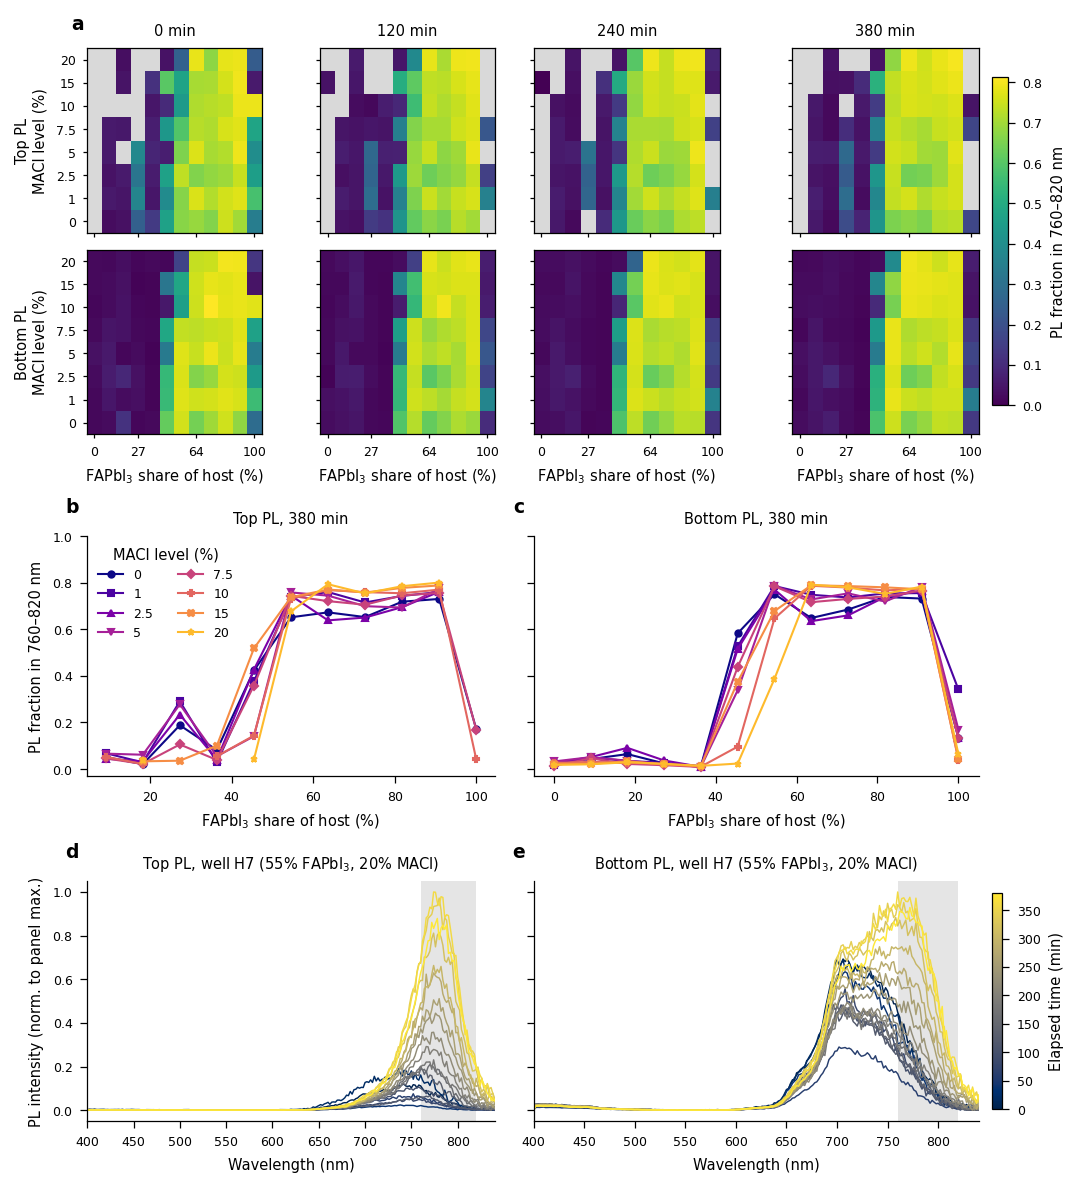

In [19]:
# ============================================================
# Publication figure for Challenge 2 (static, vector, journal-sized)
# Paste as a NEW cell after the Challenge 2 cell.
# ============================================================
import matplotlib as mpl
import matplotlib.pyplot as plt

PAPER_METRIC = "red_fraction_760_820"
PAPER_TIMES = [0, 120, 240, 380]      # snapshots shown in panel a
PAPER_WELL = "H7"                     # boundary well shown in panels d, e
BAND = (760, 820)

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 7, "axes.labelsize": 7, "axes.titlesize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "lines.linewidth": 1.0, "lines.markersize": 3,
    "pdf.fonttype": 42, "svg.fonttype": "none",   # keep text editable
    "figure.dpi": 150, "savefig.dpi": 600,
})

p_measures = sorted(rp_features["measure"].unique(), reverse=True)   # Top PL, Bottom PL
p_valid = rp_features["qc_status"].eq("valid")
p_vmax = float(rp_features.loc[p_valid, PAPER_METRIC].max())
p_grid = rp_composition.pivot(
    index="additive_percent", columns="FAPbI3_percent", values="well"
)
p_hosts = p_grid.columns.to_numpy(float)
p_levels = p_grid.index.to_numpy(float)
p_final = float(rp_features["time_min"].max())


def paper_table(measure, time_min):
    rows = rp_features[
        rp_features["measure"].eq(measure)
        & np.isclose(rp_features["time_min"], float(time_min))
    ]
    values = rows[PAPER_METRIC].where(rows["qc_status"].eq("valid"))
    values.index = rows["well"]
    return p_grid.apply(lambda column: column.map(values)).to_numpy(float)


def panel_label(ax, letter):
    ax.text(-0.02, 1.08, letter, transform=ax.transAxes, fontsize=9,
            fontweight="bold", va="bottom", ha="right")


fig = plt.figure(figsize=(7.09, 7.8), constrained_layout=True)   # 180 mm, double column
gs = fig.add_gridspec(4, 8, height_ratios=[1, 1, 1.3, 1.3])

# ---- a: plate maps, geometry (rows) x time (columns) ------------------------
map_cmap = mpl.colormaps["viridis"].copy()
map_cmap.set_bad("#d9d9d9")                                       # low/invalid PL
map_axes = []
for r, measure in enumerate(p_measures):
    for c, time_min in enumerate(PAPER_TIMES):
        ax = fig.add_subplot(gs[r, 2 * c:2 * c + 2])
        image = ax.imshow(
            np.ma.masked_invalid(paper_table(measure, time_min)),
            origin="lower", aspect="auto", cmap=map_cmap, vmin=0, vmax=p_vmax,
        )
        ax.set_xticks([0, 3, 7, 11])
        ax.set_xticklabels([f"{p_hosts[i]:.0f}" for i in (0, 3, 7, 11)])
        ax.set_yticks(range(len(p_levels)))
        ax.set_yticklabels([f"{v:g}" for v in p_levels])
        ax.tick_params(length=2)
        if r == 0:
            ax.set_title(f"{time_min:g} min")
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel("FAPbI$_3$ share of host (%)")
        if c == 0:
            ax.set_ylabel(f"{measure}\nMACl level (%)")
        else:
            ax.tick_params(labelleft=False)
        map_axes.append(ax)
panel_label(map_axes[0], "a")
fig.colorbar(image, ax=map_axes, pad=0.01, shrink=0.85,
             label=f"PL fraction in {BAND[0]}–{BAND[1]} nm")

# ---- b, c: boundary curves at the final time --------------------------------
level_colors = mpl.colormaps["plasma"](np.linspace(0.0, 0.85, len(p_levels)))
level_markers = ["o", "s", "^", "v", "D", "P", "X", "*"]
curve_axes = []
for k, measure in enumerate(p_measures):
    ax = fig.add_subplot(gs[2, 4 * k:4 * k + 4],
                         sharey=curve_axes[0] if curve_axes else None)
    table = paper_table(measure, p_final)
    for i, level in enumerate(p_levels):
        ax.plot(p_hosts, table[i], color=level_colors[i],
                marker=level_markers[i % len(level_markers)], label=f"{level:g}")
    ax.set_title(f"{measure}, {p_final:g} min")
    ax.set_xlabel("FAPbI$_3$ share of host (%)")
    ax.set_ylim(-0.03, 1.0)
    ax.spines[["top", "right"]].set_visible(False)
    if k == 0:
        ax.set_ylabel(f"PL fraction in {BAND[0]}–{BAND[1]} nm")
        ax.legend(title="MACl level (%)", ncol=2, frameon=False, loc="upper left")
    else:
        ax.tick_params(labelleft=False)
    curve_axes.append(ax)
    panel_label(ax, "bc"[k])

# ---- d, e: full spectra of one boundary well, coloured by time --------------
time_norm = mpl.colors.Normalize(0, p_final)
time_cmap = mpl.colormaps["cividis"]
spec_axes = []
well_info = rp_composition[rp_composition["well"].eq(PAPER_WELL)].iloc[0]
for k, measure in enumerate(p_measures):
    ax = fig.add_subplot(gs[3, 4 * k:4 * k + 4],
                         sharey=spec_axes[0] if spec_axes else None)
    rows = rp_features[
        rp_features["well"].eq(PAPER_WELL) & rp_features["measure"].eq(measure)
    ].sort_values("time_min")
    spectra = rp_spectra_by_id.loc[
        rows["spectrum_id"], rp_wavelength_columns
    ].to_numpy(float, copy=True)
    ok = rows["qc_status"].eq("valid").to_numpy()
    scale = np.nanmax(spectra[ok]) if ok.any() else 1.0     # one scale per panel: keeps brightness changes
    ax.axvspan(*BAND, color="#e5e5e5", lw=0)
    for spectrum, time_min, good in zip(spectra, rows["time_min"], ok):
        if good:
            ax.plot(rp_wavelengths, spectrum / scale,
                    color=time_cmap(time_norm(time_min)), lw=0.7)
    ax.set_title(
        f"{measure}, well {PAPER_WELL} "
        f"({well_info.FAPbI3_percent:.0f}% FAPbI$_3$, {well_info.additive_percent:g}% MACl)"
    )
    ax.set_xlabel("Wavelength (nm)")
    ax.set_xlim(rp_wavelengths.min(), rp_wavelengths.max())
    ax.spines[["top", "right"]].set_visible(False)
    if k == 0:
        ax.set_ylabel("PL intensity (norm. to panel max.)")
    else:
        ax.tick_params(labelleft=False)
    spec_axes.append(ax)
    panel_label(ax, "de"[k])
fig.colorbar(mpl.cm.ScalarMappable(norm=time_norm, cmap=time_cmap),
             ax=spec_axes, pad=0.01, shrink=0.9, label="Elapsed time (min)")

# ---- save vector + high-resolution raster -----------------------------------
paper_dir = DATA_ROOT / "team_exports"
paper_dir.mkdir(exist_ok=True)
for suffix in ("pdf", "svg", "png"):
    path = paper_dir / f"rp_additive_paper_figure.{suffix}"
    fig.savefig(path, bbox_inches="tight")
    display(FileLink(str(path), result_html_prefix=f"Download {suffix.upper()}: "))
plt.show()

/content/higher_dimensional_optical_data/team_exports/rp_additive_spectral_mosaic.pdf

/content/higher_dimensional_optical_data/team_exports/rp_additive_spectral_mosaic.png

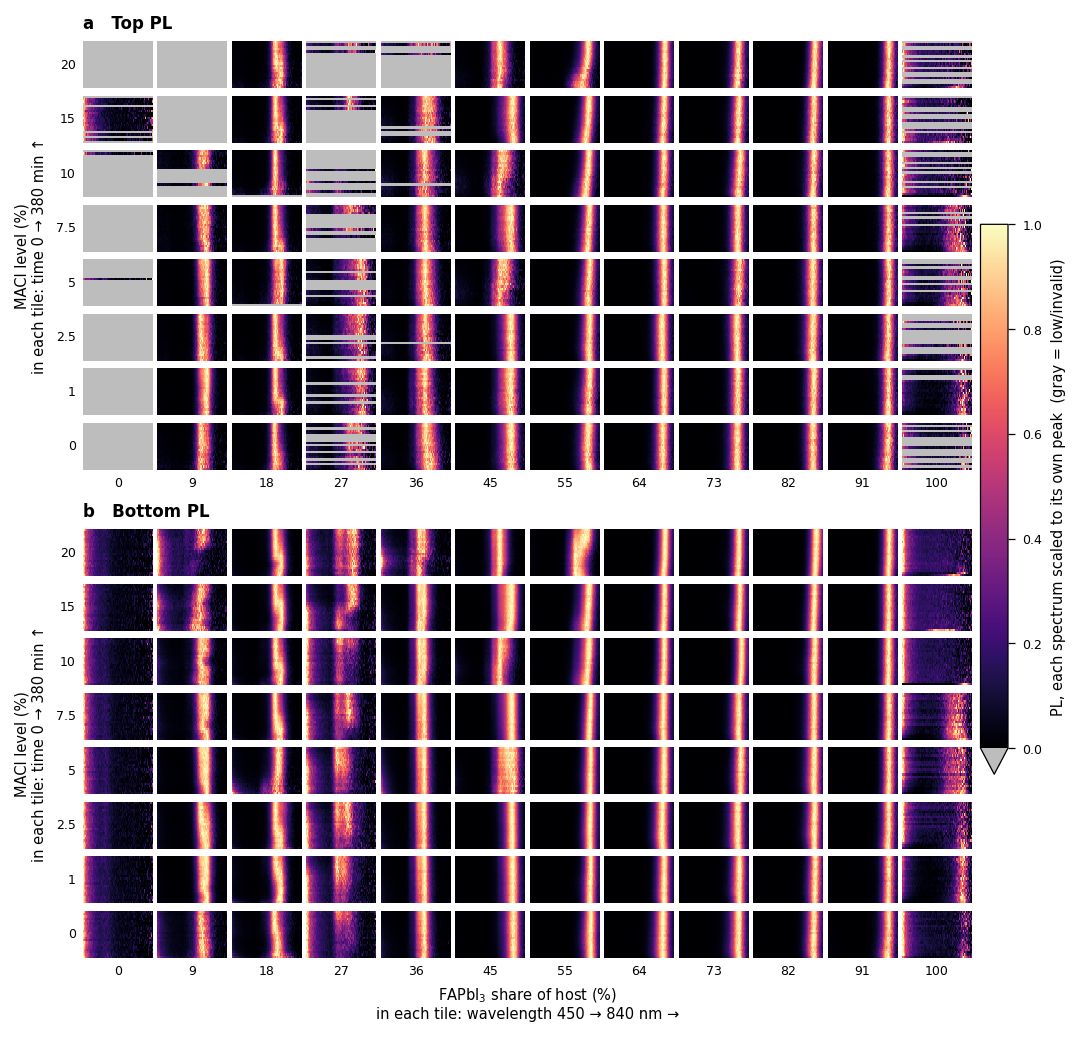

In [20]:
# ============================================================
# Spectral mosaic: every spectrum in one figure
# Tile position = recipe; inside each tile: wavelength -> , time ^
# ============================================================
import matplotlib as mpl
import matplotlib.pyplot as plt

MOSAIC_NORMALIZE = "spectrum"   # "spectrum" = shape only; "well" = keeps brightening/dimming over time
MOSAIC_WL_RANGE = (450, 840)    # nm shown inside each tile
GAP_X, GAP_Y = 14, 3            # blank pixels between tiles

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 7, "axes.labelsize": 7, "axes.titlesize": 8,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "pdf.fonttype": 42, "svg.fonttype": "none", "savefig.dpi": 600,
})

m_keep = (rp_wavelengths >= MOSAIC_WL_RANGE[0]) & (rp_wavelengths <= MOSAIC_WL_RANGE[1])
m_columns = [c for c, keep in zip(rp_wavelength_columns, m_keep) if keep]
m_grid = rp_composition.pivot(
    index="additive_percent", columns="FAPbI3_percent", values="well"
)
m_measures = sorted(rp_features["measure"].unique(), reverse=True)   # Top PL, Bottom PL
m_times = np.sort(rp_features["time_min"].unique())
n_rows, n_cols = m_grid.shape
n_t, n_wl = len(m_times), len(m_columns)
m_groups = {
    key: frame for key, frame in
    rp_features.sort_values("time_min").groupby(["well", "measure"])
}


def mosaic_tile(well, measure):
    rows = m_groups[(well, measure)]
    block = rp_spectra_by_id.loc[rows["spectrum_id"], m_columns].to_numpy(float, copy=True)
    block = np.clip(block, 0, None)
    ok = rows["qc_status"].eq("valid").to_numpy()
    if MOSAIC_NORMALIZE == "spectrum":
        scale = block.max(axis=1, keepdims=True)
    else:
        scale = np.full((len(block), 1), block[ok].max() if ok.any() else np.nan)
    scale[scale <= 0] = np.nan
    block = block / scale
    block[~ok] = -1.0                      # flagged rows -> drawn gray, not as zero
    return np.nan_to_num(block, nan=-1.0)


def build_mosaic(measure):
    image = np.full(
        (n_rows * (n_t + GAP_Y) - GAP_Y, n_cols * (n_wl + GAP_X) - GAP_X), np.nan
    )
    for i in range(n_rows):
        for j in range(n_cols):
            y0, x0 = i * (n_t + GAP_Y), j * (n_wl + GAP_X)
            image[y0:y0 + n_t, x0:x0 + n_wl] = mosaic_tile(m_grid.iat[i, j], measure)
    return image


m_cmap = mpl.colormaps["magma"].copy()
m_cmap.set_under("#bdbdbd")                # low/invalid PL
m_cmap.set_bad("white")                    # gaps between tiles

fig, axes = plt.subplots(2, 1, figsize=(7.09, 6.8), constrained_layout=True)
for ax, measure, letter in zip(axes, m_measures, "ab"):
    image = ax.imshow(
        np.ma.masked_invalid(build_mosaic(measure)), origin="lower", aspect="auto",
        cmap=m_cmap, vmin=0, vmax=1, interpolation="nearest",
    )
    ax.set_xticks([j * (n_wl + GAP_X) + n_wl / 2 for j in range(n_cols)])
    ax.set_xticklabels([f"{v:.0f}" for v in m_grid.columns])
    ax.set_yticks([i * (n_t + GAP_Y) + n_t / 2 for i in range(n_rows)])
    ax.set_yticklabels([f"{v:g}" for v in m_grid.index])
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(f"{letter}   {measure}", loc="left", fontweight="bold")
    ax.set_ylabel(
        "MACl level (%)\n"
        f"in each tile: time {m_times.min():g} → {m_times.max():g} min ↑"
    )
axes[-1].set_xlabel(
    "FAPbI$_3$ share of host (%)\n"
    f"in each tile: wavelength {MOSAIC_WL_RANGE[0]} → {MOSAIC_WL_RANGE[1]} nm →"
)
fig.colorbar(
    image, ax=axes, pad=0.01, shrink=0.6, extend="min",
    label=("PL, each spectrum scaled to its own peak" if MOSAIC_NORMALIZE == "spectrum"
           else "PL, scaled to each well's maximum") + "  (gray = low/invalid)",
)

mosaic_dir = DATA_ROOT / "team_exports"
mosaic_dir.mkdir(exist_ok=True)
for suffix in ("pdf", "png"):
    path = mosaic_dir / f"rp_additive_spectral_mosaic.{suffix}"
    fig.savefig(path, bbox_inches="tight")
    display(FileLink(str(path), result_html_prefix=f"Download {suffix.upper()}: "))
plt.show()

***Spectral phasor plot***

Used in fluorescence microscopy

idea from: https://opg.optica.org/oe/fulltext.cfm?uri=oe-20-12-12729

/content/higher_dimensional_optical_data/team_exports/rp_additive_spectral_phasor.pdf

/content/higher_dimensional_optical_data/team_exports/rp_additive_spectral_phasor.png

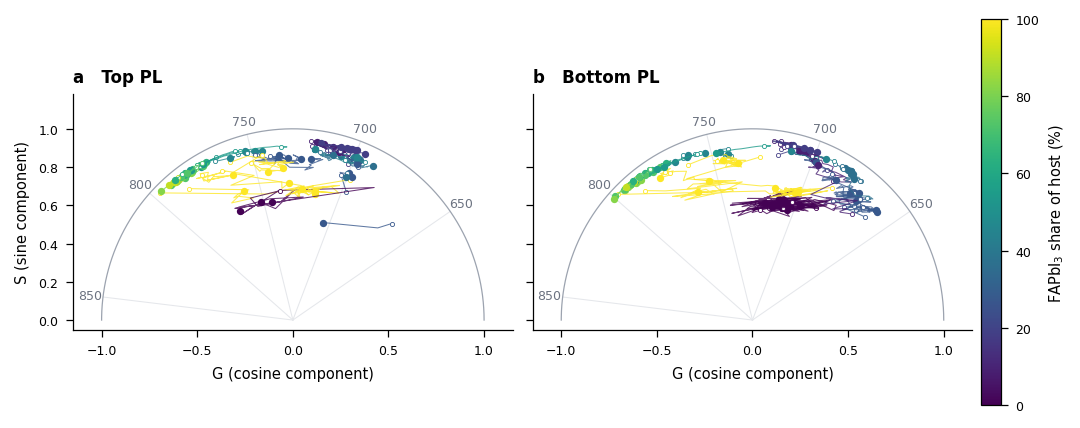

In [21]:
# ============================================================
# Spectral phasor plot: every spectrum becomes one point;
# each well becomes a trajectory through time.
# ============================================================
import matplotlib as mpl
import matplotlib.pyplot as plt

PHASOR_WINDOW = (600, 860)     # nm mapped onto a half-turn (0 to 180 degrees)
PHASOR_TICKS = [650, 700, 750, 800, 850]

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 7, "axes.labelsize": 7, "axes.titlesize": 8,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "pdf.fonttype": 42, "svg.fonttype": "none", "savefig.dpi": 600,
})


def phasor_angle(wavelength_nm):
    lo, hi = PHASOR_WINDOW
    return np.pi * (np.asarray(wavelength_nm, float) - lo) / (hi - lo)


ph_keep = (rp_wavelengths >= PHASOR_WINDOW[0]) & (rp_wavelengths <= PHASOR_WINDOW[1])
ph_columns = [c for c, keep in zip(rp_wavelength_columns, ph_keep) if keep]
ph_theta = phasor_angle(rp_wavelengths[ph_keep])

phasor = rp_features[rp_features["qc_status"].eq("valid")].copy()
ph_spectra = rp_spectra_by_id.loc[phasor["spectrum_id"], ph_columns].to_numpy(float)
ph_spectra = np.clip(
    ph_spectra - np.percentile(ph_spectra, 5, axis=1, keepdims=True), 0, None
)                                                   # remove baseline so noise does not pull points inward
ph_total = ph_spectra.sum(axis=1)
ph_total[ph_total <= 0] = np.nan
phasor["G"] = (ph_spectra * np.cos(ph_theta)).sum(axis=1) / ph_total
phasor["S"] = (ph_spectra * np.sin(ph_theta)).sum(axis=1) / ph_total
phasor = phasor.dropna(subset=["G", "S"])

ph_measures = sorted(phasor["measure"].unique(), reverse=True)     # Top PL, Bottom PL
ph_norm = mpl.colors.Normalize(0, 100)
ph_cmap = mpl.colormaps["viridis"]

fig, axes = plt.subplots(1, 2, figsize=(7.09, 3.3), sharex=True, sharey=True,
                         constrained_layout=True)
arc = phasor_angle(np.linspace(*PHASOR_WINDOW, 200))
for ax, measure, letter in zip(axes, ph_measures, "ab"):
    ax.plot(np.cos(arc), np.sin(arc), color="#9ca3af", lw=0.6)     # single-wavelength limit
    for tick in PHASOR_TICKS:
        angle = phasor_angle(tick)
        ax.plot([0, np.cos(angle)], [0, np.sin(angle)], color="#e5e7eb", lw=0.5, zorder=0)
        ax.text(1.07 * np.cos(angle), 1.07 * np.sin(angle), f"{tick}",
                ha="center", va="center", fontsize=6, color="#6b7280")
    subset = phasor[phasor["measure"].eq(measure)].sort_values("time_min")
    for well, track in subset.groupby("well"):
        color = ph_cmap(ph_norm(track["FAPbI3_percent"].iloc[0]))
        ax.plot(track["G"], track["S"], color=color, lw=0.5, alpha=0.8)
        ax.plot(track["G"].iloc[0], track["S"].iloc[0], marker="o", ms=2,
                mfc="white", mec=color, mew=0.4)                    # start
        ax.plot(track["G"].iloc[-1], track["S"].iloc[-1], marker="o", ms=2.5,
                color=color)                                        # end
    ax.set_title(f"{letter}   {measure}", loc="left", fontweight="bold")
    ax.set_aspect("equal")
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-0.05, 1.18)
    ax.set_xlabel("G (cosine component)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("S (sine component)")
fig.colorbar(mpl.cm.ScalarMappable(norm=ph_norm, cmap=ph_cmap), ax=axes,
             pad=0.01, shrink=0.8, label="FAPbI$_3$ share of host (%)")

ph_dir = DATA_ROOT / "team_exports"
ph_dir.mkdir(exist_ok=True)
for suffix in ("pdf", "png"):
    path = ph_dir / f"rp_additive_spectral_phasor.{suffix}"
    fig.savefig(path, bbox_inches="tight")
    display(FileLink(str(path), result_html_prefix=f"Download {suffix.upper()}: "))
plt.show()

- Like a protractor, the spoke denotes the wavelength
- Farther away from origin - sharper the peak
- ○ = spectrum at 1st time point (0th min)
- ● = spectrum at last time point (380th min)
- Line connecting  ○ and ● shows time path



/content/higher_dimensional_optical_data/team_exports/rp_additive_phasor_glow.pdf

/content/higher_dimensional_optical_data/team_exports/rp_additive_phasor_glow.png

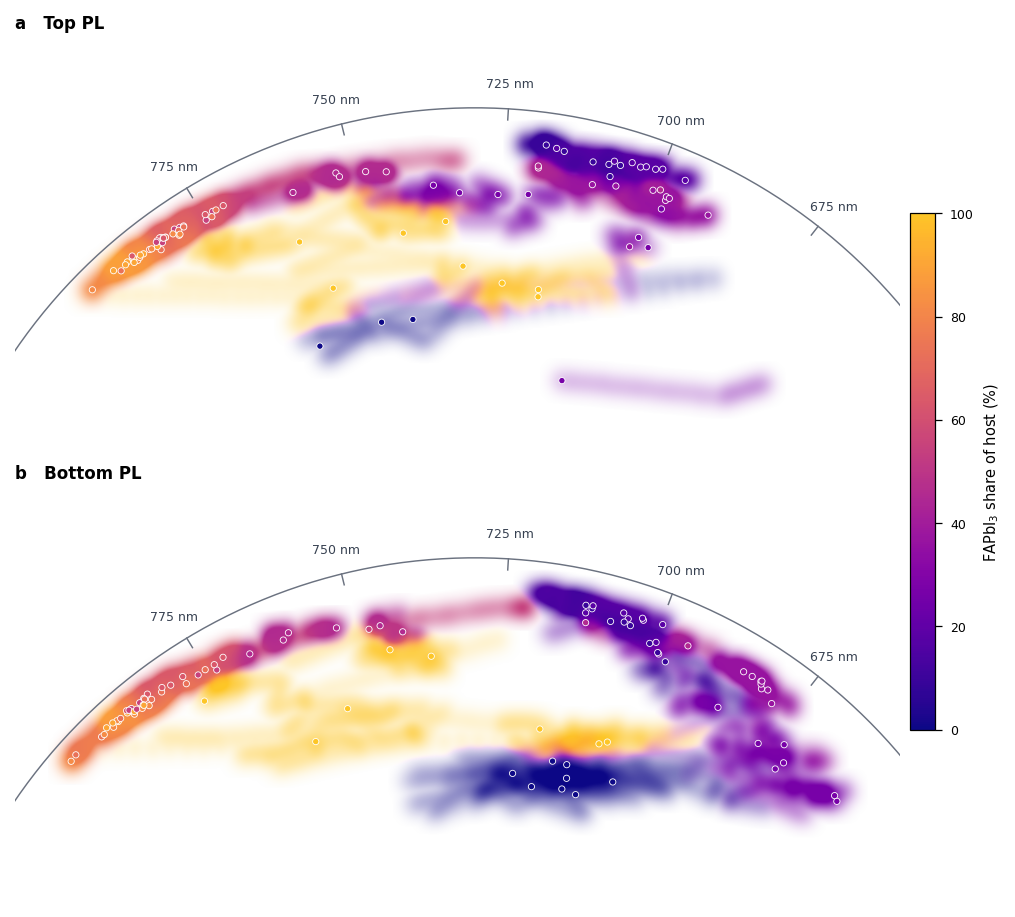

In [23]:
# ============================================================
# Glow phasor map, v2: cropped to the data, light background,
# brightness evened out, end points drawn as crisp dots
# ============================================================
from scipy.ndimage import gaussian_filter
from matplotlib.colors import ListedColormap

GLOW_BINS = 800        # image resolution across
GLOW_BLUR = 5          # smoothing in pixels (bigger = softer)
GLOW_STEPS = 25        # points filled in between consecutive time points
GLOW_GAMMA = 0.35      # < 1 lifts faint regions
GLOW_CMAP = ListedColormap(mpl.colormaps["plasma"](np.linspace(0.0, 0.88, 256)))

pad = 0.10
glow_xlim = (phasor["G"].min() - pad, phasor["G"].max() + pad)
glow_ylim = (phasor["S"].min() - pad, 1.12)
glow_x = np.linspace(*glow_xlim, GLOW_BINS + 1)
glow_y = np.linspace(
    *glow_ylim,
    int(GLOW_BINS * (glow_ylim[1] - glow_ylim[0]) / (glow_xlim[1] - glow_xlim[0])) + 1,
)


def glow_image(measure):
    xs, ys, hosts = [], [], []
    subset = phasor[phasor["measure"].eq(measure)].sort_values("time_min")
    for _, track in subset.groupby("well"):
        g, s = track["G"].to_numpy(), track["S"].to_numpy()
        if len(g) < 2:
            continue
        steps = np.arange(len(g))
        fine = np.linspace(0, len(g) - 1, (len(g) - 1) * GLOW_STEPS + 1)
        xs.append(np.interp(fine, steps, g))
        ys.append(np.interp(fine, steps, s))
        hosts.append(np.full(fine.size, track["FAPbI3_percent"].iloc[0]))
    x, y, host = map(np.concatenate, (xs, ys, hosts))
    density, _, _ = np.histogram2d(y, x, bins=[glow_y, glow_x])
    weighted, _, _ = np.histogram2d(y, x, bins=[glow_y, glow_x], weights=host)
    density = gaussian_filter(density, GLOW_BLUR)
    weighted = gaussian_filter(weighted, GLOW_BLUR)
    mean_host = np.divide(weighted, density, out=np.zeros_like(weighted),
                          where=density > 1e-9)
    ceiling = np.percentile(density[density > 1e-9], 90)      # stop one dense cluster dimming the rest
    strength = np.clip(density / ceiling, 0, 1) ** GLOW_GAMMA
    image = GLOW_CMAP(mean_host / 100.0)
    image[..., 3] = strength                                   # faint regions fade to white, not to mud
    return image


fig, axes = plt.subplots(2, 1, figsize=(7.09, 6.0), constrained_layout=True)
arc = phasor_angle(np.linspace(*PHASOR_WINDOW, 400))
for ax, measure, letter in zip(axes, ph_measures, "ab"):
    ax.imshow(glow_image(measure), origin="lower", interpolation="bilinear",
              extent=[*glow_xlim, *glow_ylim], zorder=1)
    ax.plot(np.cos(arc), np.sin(arc), color="#6b7280", lw=0.7, zorder=2)
    for tick in range(PHASOR_WINDOW[0], PHASOR_WINDOW[1] + 1, 25):
        angle = phasor_angle(tick)
        tx, ty = 1.045 * np.cos(angle), 1.045 * np.sin(angle)
        if not (glow_xlim[0] + 0.05 < tx < glow_xlim[1] - 0.05 and ty > glow_ylim[0] + 0.03):
            continue
        ax.plot([0.98 * np.cos(angle), np.cos(angle)], [0.98 * np.sin(angle), np.sin(angle)],
                color="#6b7280", lw=0.7, zorder=2)
        ax.text(tx, ty, f"{tick} nm", ha="center", va="center", fontsize=6, color="#374151")
    ends = (phasor[phasor["measure"].eq(measure)]
            .sort_values("time_min").groupby("well").tail(1))
    ax.scatter(ends["G"], ends["S"], c=ends["FAPbI3_percent"], cmap=GLOW_CMAP,
               vmin=0, vmax=100, s=9, edgecolor="white", linewidth=0.4, zorder=3)
    ax.set_title(f"{letter}   {measure}", loc="left", fontweight="bold")
    ax.set_aspect("equal")
    ax.set_xlim(*glow_xlim)
    ax.set_ylim(*glow_ylim)
    ax.axis("off")
fig.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, 100), cmap=GLOW_CMAP),
    ax=axes, pad=0.01, shrink=0.6, label="FAPbI$_3$ share of host (%)",
)

glow_dir = DATA_ROOT / "team_exports"
glow_dir.mkdir(exist_ok=True)
for suffix in ("pdf", "png"):
    path = glow_dir / f"rp_additive_phasor_glow.{suffix}"
    fig.savefig(path, bbox_inches="tight")
    display(FileLink(str(path), result_html_prefix=f"Download {suffix.upper()}: "))
plt.show()

***False-colour composite***

Used in satellite imaging and astronomy

Ref paper: https://arxiv.org/abs/astro-ph/0412138


*   Colour tells where in wavelength each spectrum's emission sits
*   Add up the light in each band. The code sums the intensity within 600–680 nm, 680–760 nm and 760–840 nm, then divides each sum by the total of the three. That gives three fractions that add up to 1.
*   Use the fractions as a colour. A screen colour is a mix of red, green and blue, each from 0 to 1. The long-band fraction becomes the red amount, the middle-band fraction the green amount, and the short-band fraction the blue amount.
* Brighten to full strength. All three amounts are divided by the largest of them, so the strongest channel is always 1. This keeps the hue but stops every tile looking dark.



/content/higher_dimensional_optical_data/team_exports/rp_additive_false_colour.pdf

/content/higher_dimensional_optical_data/team_exports/rp_additive_false_colour.png

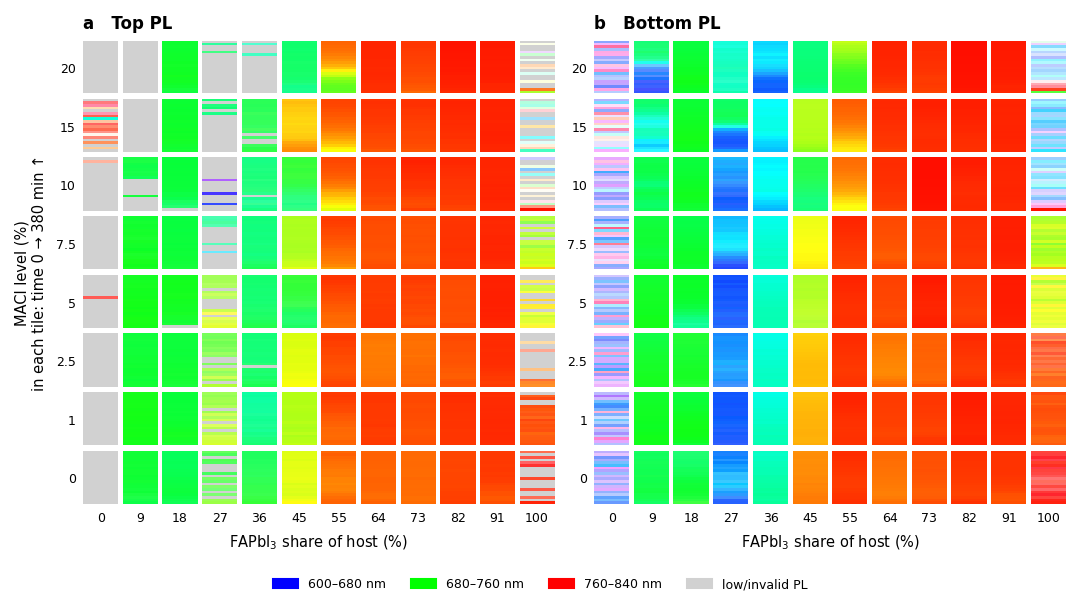

In [24]:
# ============================================================
# False-colour composite: three wavelength bands -> blue, green, red
# Each well = one vertical strip (time bottom -> top) at its recipe position
# ============================================================
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

FC_BANDS = [(600, 680), (680, 760), (760, 840)]                 # nm
FC_COLORS = np.array([[0, 0, 1], [0, 1, 0], [1, 0, 0]], float)  # colour given to each band
FC_BRIGHTNESS = "none"     # "none" = colour shows shape only; "well" = also dim by intensity within a well
FC_GRAY = 0.82             # low/invalid PL
FC_TILE_W, FC_GAP_X, FC_GAP_Y = 8, 1, 2

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 7, "axes.labelsize": 7, "axes.titlesize": 8,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "pdf.fonttype": 42, "svg.fonttype": "none", "savefig.dpi": 600,
})

fc = rp_features[["well", "measure", "time_min", "qc_status"]].copy()
fc_spectra = rp_spectra_by_id.loc[
    rp_features["spectrum_id"], rp_wavelength_columns
].to_numpy(float)
fc_spectra = np.clip(
    fc_spectra - np.percentile(fc_spectra, 5, axis=1, keepdims=True), 0, None
)
fc_band_sums = np.column_stack([
    fc_spectra[:, (rp_wavelengths >= lo) & (rp_wavelengths <= hi)].sum(axis=1)
    for lo, hi in FC_BANDS
])
fc_total = fc_band_sums.sum(axis=1)
with np.errstate(invalid="ignore", divide="ignore"):
    fc_rgb = (fc_band_sums / fc_total[:, None]) @ FC_COLORS
    fc_rgb = fc_rgb / fc_rgb.max(axis=1, keepdims=True)         # strongest channel = full
fc_ok = fc["qc_status"].eq("valid").to_numpy() & np.isfinite(fc_rgb).all(axis=1)

if FC_BRIGHTNESS == "well":
    fc["total"] = np.where(fc_ok, fc_total, np.nan)
    relative = fc["total"] / fc.groupby(["well", "measure"])["total"].transform("max")
    fc_rgb = fc_rgb * np.sqrt(relative.to_numpy())[:, None]
fc_rgb[~fc_ok] = FC_GRAY
fc[["r", "g", "b"]] = np.nan_to_num(fc_rgb, nan=FC_GRAY)

fc_grid = rp_composition.pivot(
    index="additive_percent", columns="FAPbI3_percent", values="well"
)
fc_measures = sorted(fc["measure"].unique(), reverse=True)       # Top PL, Bottom PL
fc_times = np.sort(fc["time_min"].unique())
fc_rows, fc_cols, fc_nt = fc_grid.shape[0], fc_grid.shape[1], len(fc_times)
fc_groups = {
    key: frame[["r", "g", "b"]].to_numpy(float)
    for key, frame in fc.sort_values("time_min").groupby(["well", "measure"])
}


def false_colour_plate(measure):
    image = np.ones((
        fc_rows * (fc_nt + FC_GAP_Y) - FC_GAP_Y,
        fc_cols * (FC_TILE_W + FC_GAP_X) - FC_GAP_X, 3,
    ))
    for i in range(fc_rows):
        for j in range(fc_cols):
            strip = fc_groups[(fc_grid.iat[i, j], measure)]
            y0, x0 = i * (fc_nt + FC_GAP_Y), j * (FC_TILE_W + FC_GAP_X)
            image[y0:y0 + len(strip), x0:x0 + FC_TILE_W] = strip[:, None, :]
    return image


fig, axes = plt.subplots(1, 2, figsize=(7.09, 3.9), constrained_layout=True)
for ax, measure, letter in zip(axes, fc_measures, "ab"):
    ax.imshow(false_colour_plate(measure), origin="lower", aspect="auto",
              interpolation="nearest")
    ax.set_xticks([j * (FC_TILE_W + FC_GAP_X) + (FC_TILE_W - 1) / 2 for j in range(fc_cols)])
    ax.set_xticklabels([f"{v:.0f}" for v in fc_grid.columns])
    ax.set_yticks([i * (fc_nt + FC_GAP_Y) + (fc_nt - 1) / 2 for i in range(fc_rows)])
    ax.set_yticklabels([f"{v:g}" for v in fc_grid.index])
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(f"{letter}   {measure}", loc="left", fontweight="bold")
    ax.set_xlabel("FAPbI$_3$ share of host (%)")
axes[0].set_ylabel(
    f"MACl level (%)\nin each tile: time {fc_times.min():g} → {fc_times.max():g} min ↑"
)
fig.legend(
    handles=[
        Patch(color=FC_COLORS[k], label=f"{lo}–{hi} nm")
        for k, (lo, hi) in enumerate(FC_BANDS)
    ] + [Patch(color=(FC_GRAY,) * 3, label="low/invalid PL")],
    loc="outside lower center", ncol=4, frameon=False,
)

fc_dir = DATA_ROOT / "team_exports"
fc_dir.mkdir(exist_ok=True)
for suffix in ("pdf", "png"):
    path = fc_dir / f"rp_additive_false_colour.{suffix}"
    fig.savefig(path, bbox_inches="tight")
    display(FileLink(str(path), result_html_prefix=f"Download {suffix.upper()}: "))
plt.show()

***Hovmöller diagram***

/content/higher_dimensional_optical_data/team_exports/rp_additive_hovmoller.pdf

/content/higher_dimensional_optical_data/team_exports/rp_additive_hovmoller.png

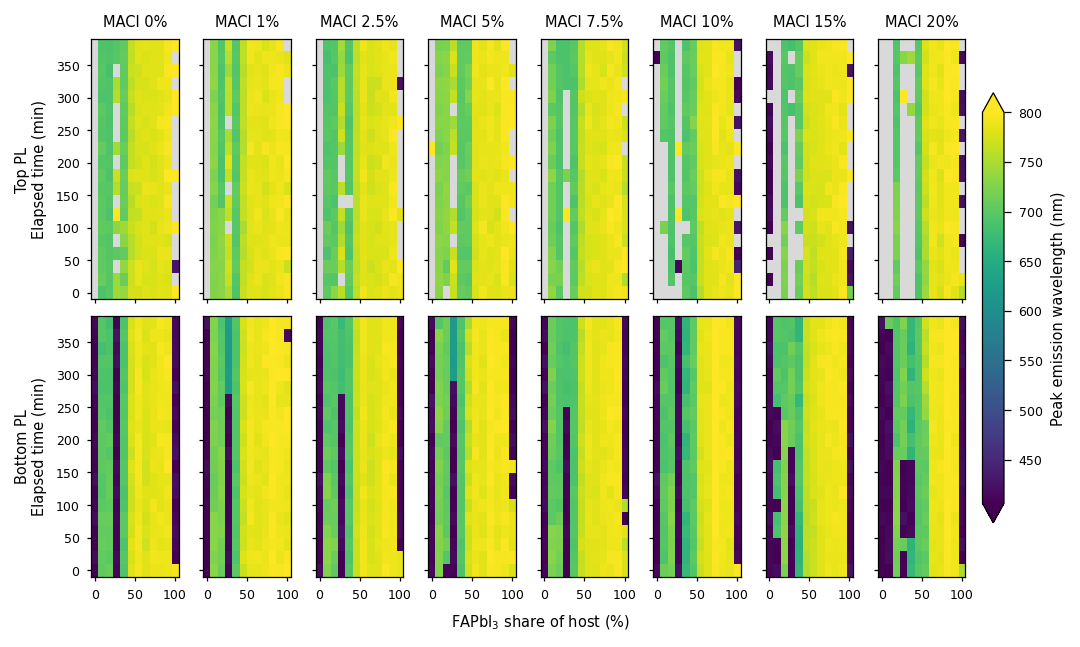

In [25]:
# ============================================================
# Hovmöller diagram: time (up) vs FAPbI3 share (across), one panel per MACl level
# ============================================================
import matplotlib as mpl
import matplotlib.pyplot as plt

HOV_METRIC = "peak_nm"                    # or "red_fraction_760_820"
HOV_LABEL = "Peak emission wavelength (nm)"
HOV_CMAP = "viridis"

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 7, "axes.labelsize": 7, "axes.titlesize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "pdf.fonttype": 42, "svg.fonttype": "none", "savefig.dpi": 600,
})

hov = rp_features.assign(
    shown=rp_features[HOV_METRIC].where(rp_features["qc_status"].eq("valid"))
)
hov_grid = rp_composition.pivot(
    index="additive_percent", columns="FAPbI3_percent", values="well"
)
hov_measures = sorted(hov["measure"].unique(), reverse=True)     # Top PL, Bottom PL
hov_levels = list(hov_grid.index)
hov_times = np.sort(hov["time_min"].unique())
hov_step = float(np.diff(hov_times).mean())
hov_vmin, hov_vmax = np.nanpercentile(hov["shown"], [2, 98])     # ignore a few extreme values
hov_cmap = mpl.colormaps[HOV_CMAP].copy()
hov_cmap.set_bad("#d9d9d9")                                      # low/invalid PL


def hovmoller_table(measure, level):
    subset = hov[hov["measure"].eq(measure)]
    table = subset.pivot(index="time_min", columns="well", values="shown")
    return table.reindex(index=hov_times, columns=list(hov_grid.loc[level])).to_numpy(float)


fig, axes = plt.subplots(
    len(hov_measures), len(hov_levels), figsize=(7.09, 4.2),
    sharex=True, sharey=True, constrained_layout=True,
)
n_hosts = hov_grid.shape[1]
for r, measure in enumerate(hov_measures):
    for c, level in enumerate(hov_levels):
        ax = axes[r, c]
        image = ax.imshow(
            np.ma.masked_invalid(hovmoller_table(measure, level)),
            origin="lower", aspect="auto", cmap=hov_cmap,
            vmin=hov_vmin, vmax=hov_vmax, interpolation="nearest",
            extent=[-0.5, n_hosts - 0.5,
                    hov_times.min() - hov_step / 2, hov_times.max() + hov_step / 2],
        )
        ax.set_xticks([0, (n_hosts - 1) / 2, n_hosts - 1])
        ax.set_xticklabels(["0", "50", "100"])
        ax.tick_params(length=2)
        if r == 0:
            ax.set_title(f"MACl {level:g}%")
        if c == 0:
            ax.set_ylabel(f"{measure}\nElapsed time (min)")
fig.supxlabel("FAPbI$_3$ share of host (%)", fontsize=7)
fig.colorbar(image, ax=axes, pad=0.01, shrink=0.8, extend="both", label=HOV_LABEL)

hov_dir = DATA_ROOT / "team_exports"
hov_dir.mkdir(exist_ok=True)
for suffix in ("pdf", "png"):
    path = hov_dir / f"rp_additive_hovmoller.{suffix}"
    fig.savefig(path, bbox_inches="tight")
    display(FileLink(str(path), result_html_prefix=f"Download {suffix.upper()}: "))
plt.show()

<h2><font color="purple">4.</font> Build, Test, and Explain Your Design</h2>

Use a **60-second usability test**: hand the visualization to someone from another team
and ask them to answer your scientific question without coaching.

Score one point for each:

1. **Dimensional fidelity:** important variables are shown, encoded, or selectable.
2. **Overview + evidence:** a trend can be found and its spectra inspected.
3. **Spectral honesty:** summaries do not masquerade as phase assignments.
4. **Comparable scales + QC:** time/geometry comparisons use defensible scales, and
   low/invalid PL is visibly distinct from measured zero.
5. **One-minute usability:** a new user can answer the stated question.


In [ ]:
# @title 5. Team result — edit these three fields
TEAM_NAME = "" # @param {type:"string"}
CHOSEN_CHALLENGE = "Challenge 1 — Quaternary System" # @param ["Challenge 1 — Quaternary System", "Challenge 2 — RP-Additive System"]
DESIGN_CLAIM = "" # @param {type:"string"}

TEAM_FIGURES = (
    challenge1_figures
    if CHOSEN_CHALLENGE.startswith("Challenge 1")
    else challenge2_figures
)
display(Markdown(
    f"### {TEAM_NAME or 'Unnamed team'}\n\n"
    f"**{CHOSEN_CHALLENGE}**\n\n"
    f"{DESIGN_CLAIM or 'Add one sentence explaining what became easier to see.'}"
))
show_figures(TEAM_FIGURES)


### Unnamed team

**Challenge 1 — Quaternary System**

Add one sentence explaining what became easier to see.

In [ ]:
# @title 6. Export the final interactive result
safe_team = "".join(
    character if character.isalnum() or character in "-_" else "_"
    for character in (TEAM_NAME.strip() or "unnamed_team")
)
export_dir = DATA_ROOT / "team_exports"
export_dir.mkdir(exist_ok=True)
export_path = export_figure_grid(
    TEAM_FIGURES,
    export_dir / f"{safe_team}_final_visualization.html",
    f"{TEAM_NAME or 'Unnamed team'} — {CHOSEN_CHALLENGE}",
)
print("Wrote", export_path)
display(FileLink(str(export_path), result_html_prefix="Download interactive HTML: "))


Wrote /content/higher_dimensional_optical_data/team_exports/unnamed_team_final_visualization.html


/content/higher_dimensional_optical_data/team_exports/unnamed_team_final_visualization.html

## Final Discussion

Be ready to answer:

1. What became easier to see?
2. Which dimensions are directly shown, encoded, selected, or omitted?
3. What could the design cause someone to assume incorrectly?
4. Does the conclusion still hold when the full spectra are inspected?
5. What would you change with another hour?

---

## <font color="green">Takeaway</font>

A useful higher-dimensional visualization does not merely make the plot look compact.
It preserves the scientific variables, exposes comparison choices, distinguishes bad
signal from measured zero, and keeps the underlying spectra inspectable.


## Optional Appendix — Data Provenance and Limits

**Quaternary System:** 96 static wells; one Top PL, Bottom PL, and absorbance read per well.
Nominal composition fractions assume equal-molar stocks. Stock concentrations and
solvents are not included.

**RP-Additive System:** 96 wells × 20 times × two geometries = 3,840 PL spectra. The MACl
percentage is a nominal design label with undocumented denominator. The dispense table
was reconstructed from project plate-layout code and cross-checked against all 96
metadata labels; it was not parsed from the plate-reader workbook.

Each downloaded challenge folder includes `README_DATA.md` and `SHA256SUMS.txt` for a
fuller field description and file-integrity record.
